# Modeling - Baseline. 
Only with the Current engineered telecom features only

In [35]:
import json
import re
import math
import numpy as np
import pandas as pd
from io import StringIO

## Feature Engineering

In [36]:
def parse_tables(question):
    text = question.replace("\r\n", "\n").replace("\r", "\n")

    user_match = re.search(
        r"User plane drive test data as follows[：:]\s*\n+(.*?)(?:\n\s*\n\s*Engeneering parameters data as follows[：:]|\n\s*\n\s*Engineering parameters data as follows[：:])",
        text,
        flags=re.S
    )

    eng_match = re.search(
        r"(?:Engeneering|Engineering) parameters data as follows[：:]\s*\n+(.*)$",
        text,
        flags=re.S
    )

    if not user_match or not eng_match:
        raise ValueError("Could not find table blocks")

    def block_to_df(block):
        lines = []
        for line in block.splitlines():
            line = line.strip()
            if "|" in line:
                lines.append(line)

        # Repairs rare formatting issue like "g\nNodeB ID"
        if lines and lines[0].startswith("NodeB ID|"):
            lines[0] = "g" + lines[0]

        return pd.read_csv(StringIO("\n".join(lines)), sep="|")

    user_df = block_to_df(user_match.group(1))
    eng_df = block_to_df(eng_match.group(1))

    return user_df, eng_df


def beamwidth_from_scenario(s):
    if pd.isna(s):
        return np.nan

    s = str(s).upper()

    if "DEFAULT" in s:
        return 6

    match = re.search(r"SCENARIO_(\d+)", s)
    if match:
        n = int(match.group(1))
        if n <= 5:
            return 6
        elif n <= 11:
            return 12
        else:
            return 25

    return np.nan

# Calculate distance between vehicle GPS location and tower location
# C2: coverage distance exceeds 1 km -> To calculate distance
def haversine(lon1, lat1, lon2, lat2):
    R = 6371.0

    lon1, lat1, lon2, lat2 = map(
        np.radians,
        [lon1, lat1, lon2, lat2]
    )

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))

# longest consecutive streak of low throughput
def longest_streak_bool(values):
    max_streak = 0
    current = 0

    for value in values:
        if bool(value):
            current += 1
            max_streak = max(max_streak, current)
        else:
            current = 0

    return max_streak

def make_features(user_df, eng_df):
    # Taking care of missing data "-" as NaN
    user_df = user_df.copy().replace("-", np.nan)
    eng_df = eng_df.copy().replace("-", np.nan)

    # Define important column names
    tp_col = "5G KPI PCell Layer2 MAC DL Throughput [Mbps]"
    speed_col = "GPS Speed (km/h)"
    # "What cell is the UE connected to?"
    pci_col = "5G KPI PCell RF Serving PCI"
    # "How strong is the signal?"
    rsrp_col = "5G KPI PCell RF Serving SS-RSRP [dBm]"
    # "How clean is the signal?"
    sinr_col = "5G KPI PCell RF Serving SS-SINR [dB]"
    # "How many RBs are being used?"
    rb_col = "5G KPI PCell Layer1 DL RB Num (Including 0)"

    neighbor_pci_cols = [
        f"Measurement PCell Neighbor Cell Top Set(Cell Level) Top {i} PCI"
        for i in range(1, 6)
    ]

    neighbor_brsrp_cols = [
        f"Measurement PCell Neighbor Cell Top Set(Cell Level) Top {i} Filtered Tx BRSRP [dBm]"
        for i in range(1, 6)
    ]

    numeric_user_cols = [
        "Longitude", "Latitude",
        tp_col, speed_col, pci_col, rsrp_col, sinr_col, rb_col
    ] + neighbor_pci_cols + neighbor_brsrp_cols

    # Convert text numbers into numeric values
    for col in numeric_user_cols:
        if col in user_df.columns:
            user_df[col] = pd.to_numeric(user_df[col], errors="coerce")

    numeric_eng_cols = [
        "Longitude", "Latitude", "Mechanical Downtilt",
        "Digital Tilt", "Height", "PCI"
    ]

    for col in numeric_eng_cols:
        eng_df[col] = pd.to_numeric(eng_df[col], errors="coerce")

    # Engineering transformations
    # we replace 255 with 6.
    eng_df["digital_tilt_clean"] = eng_df["Digital Tilt"].replace(255, 6)
    # effective_tilt = mechanical downtilt + digital tilt -> Can be useful for C1: downtilt too large
    eng_df["effective_tilt"] = (
        eng_df["Mechanical Downtilt"] + eng_df["digital_tilt_clean"]
    )
    eng_df["beamwidth"] = eng_df["Beam Scenario"].apply(beamwidth_from_scenario)

    #print("Engineering data after transformations:")
    #print(eng_df)

    eng_by_pci = (
        eng_df
        .dropna(subset=["PCI"])
        .drop_duplicates("PCI")
        .set_index("PCI")
    )

    features = {}

    tp = user_df[tp_col]
    low_mask = tp < 600
    low_df = user_df[low_mask]

    # -----------------------------
    # Throughput features
    # -----------------------------
    features["avg_throughput"] = tp.mean()
    features["min_throughput"] = tp.min()
    features["std_throughput"] = tp.std()
    features["low_tp_count"] = int(low_mask.sum())
    features["low_tp_ratio"] = low_mask.mean()
    features["avg_throughput_low_tp"] = low_df[tp_col].mean()
    features["consecutive_low_tp_max"] = longest_streak_bool(low_mask.tolist())

    # -----------------------------
    # Speed features
    # -----------------------------
    speed = user_df[speed_col]

    features["max_speed"] = speed.max()
    features["pct_speed_above_40"] = (speed > 40).mean()
    features["avg_speed_low_tp"] = low_df[speed_col].mean()
    features["max_speed_low_tp"] = low_df[speed_col].max()

    # -----------------------------
    # Handover features
    # -----------------------------
    serving_pci = user_df[pci_col]

    features["num_unique_serving_pci"] = serving_pci.nunique()

    switches = (
        (serving_pci != serving_pci.shift())
        & serving_pci.notna()
        & serving_pci.shift().notna()
    )

    features["handover_count"] = int(switches.sum())
    features["handover_rate"] = features["handover_count"] / max(len(user_df) - 1, 1)

    if len(low_df) > 1:
        low_pci = low_df[pci_col]
        low_switches = (
            (low_pci != low_pci.shift())
            & low_pci.notna()
            & low_pci.shift().notna()
        )
        features["handover_count_low_tp"] = int(low_switches.sum())
    else:
        features["handover_count_low_tp"] = 0

    # -----------------------------
    # Signal quality features
    # -----------------------------
    features["avg_rsrp"] = user_df[rsrp_col].mean()
    features["min_rsrp"] = user_df[rsrp_col].min()
    features["avg_rsrp_low_tp"] = low_df[rsrp_col].mean()

    features["avg_sinr"] = user_df[sinr_col].mean()
    features["min_sinr"] = user_df[sinr_col].min()
    features["avg_sinr_low_tp"] = low_df[sinr_col].mean()


    # NEW SINR FEATURES
    features["std_sinr"] = user_df[sinr_col].std()

    SINR_THRESHOLD = 5
    features["pct_sinr_below_5"] = (user_df[sinr_col] < SINR_THRESHOLD).mean()

    features["min_sinr_low_tp"] = low_df[sinr_col].min()

    # -----------------------------
    # RB features
    # -----------------------------
    rb = user_df[rb_col]

    features["avg_rb"] = rb.mean()
    features["min_rb"] = rb.min()
    features["avg_rb_low_tp"] = low_df[rb_col].mean()
    features["min_rb_low_tp"] = low_df[rb_col].min()
    features["pct_rb_below_160"] = (rb < 160).mean()
    

    # -----------------------------
    # Neighbor + PCI mod 30 features
    # -----------------------------
    neighbor_advantages = []
    neighbor_stronger_flags = []
    close_neighbor_counts = []
    same_mod30_flags = []
    same_mod30_counts = []

    for _, row in user_df.iterrows():
        serving_rsrp = row[rsrp_col]
        serving_pci_value = row[pci_col]

        neighbor_brsrps = [
            row[col] for col in neighbor_brsrp_cols
            if col in user_df.columns and pd.notna(row[col])
        ]

        neighbor_pcis = [
            row[col] for col in neighbor_pci_cols
            if col in user_df.columns
        ]

        # Neighbor strength
        if neighbor_brsrps and pd.notna(serving_rsrp):
            strongest_neighbor = max(neighbor_brsrps)
            advantage = strongest_neighbor - serving_rsrp

            neighbor_advantages.append(advantage)
            neighbor_stronger_flags.append(strongest_neighbor > serving_rsrp)

            close_count = sum(
                abs(x - serving_rsrp) <= 3
                for x in neighbor_brsrps
            )
            close_neighbor_counts.append(close_count)

        # PCI mod 30 conflict
        mod30_count = 0

        if pd.notna(serving_pci_value):
            for neighbor_pci in neighbor_pcis:
                if pd.notna(neighbor_pci):
                    if int(neighbor_pci) % 30 == int(serving_pci_value) % 30:
                        mod30_count += 1

        same_mod30_counts.append(mod30_count)
        same_mod30_flags.append(mod30_count > 0)

    features["avg_neighbor_advantage"] = (
        np.nanmean(neighbor_advantages) if neighbor_advantages else np.nan
    )
    features["max_neighbor_advantage"] = (
        np.nanmax(neighbor_advantages) if neighbor_advantages else np.nan
    )
    features["neighbor_stronger_ratio"] = (
        np.mean(neighbor_stronger_flags) if neighbor_stronger_flags else np.nan
    )
    features["avg_close_neighbor_count"] = (
        np.nanmean(close_neighbor_counts) if close_neighbor_counts else np.nan
    )
    features["overlap_ratio"] = (
        np.mean([x > 0 for x in close_neighbor_counts])
        if close_neighbor_counts else np.nan
    )

    features["same_mod30_exists"] = int(any(same_mod30_flags))
    features["same_mod30_count"] = np.sum(same_mod30_counts)
    features["same_mod30_ratio"] = np.mean(same_mod30_flags)

    # ----------------------------------------
    # TxRx Mode (categorical)
    # ----------------------------------------

    txrx_vals = eng_df["TxRx Mode"].dropna()

    features["txrx_mode"] = (
        txrx_vals.mode().iloc[0]
        if len(txrx_vals) > 0
        else "Unknown"
    )

    # ----------------------------------------
    # Antenna Model (categorical)
    # ----------------------------------------

    antenna_vals = eng_df["Antenna Model"].dropna()

    features["antenna_model"] = (
        antenna_vals.mode().iloc[0]
        if len(antenna_vals) > 0
        else "Unknown"
    )

    # -----------------------------
    # Engineering + distance features
    # -----------------------------
    serving_tilts = []
    serving_beamwidths = []
    serving_heights = []
    serving_distances = []
    serving_distances_low_tp = []

    for idx, row in user_df.iterrows():
        serving_pci_value = row[pci_col]

        if pd.notna(serving_pci_value) and serving_pci_value in eng_by_pci.index:
            eng_row = eng_by_pci.loc[serving_pci_value]

            serving_tilts.append(eng_row["effective_tilt"])
            serving_beamwidths.append(eng_row["beamwidth"])
            serving_heights.append(eng_row["Height"])

            dist = haversine(
                row["Longitude"],
                row["Latitude"],
                eng_row["Longitude"],
                eng_row["Latitude"]
            )

            serving_distances.append(dist)

            if low_mask.iloc[idx]:
                serving_distances_low_tp.append(dist)

    features["avg_serving_tilt"] = (
        np.nanmean(serving_tilts) if serving_tilts else np.nan
    )
    features["max_serving_tilt"] = (
        np.nanmax(serving_tilts) if serving_tilts else np.nan
    )
    features["avg_serving_beamwidth"] = (
        np.nanmean(serving_beamwidths) if serving_beamwidths else np.nan
    )
    features["avg_serving_height"] = (
        np.nanmean(serving_heights) if serving_heights else np.nan
    )

    features["avg_serving_distance_km"] = (
        np.nanmean(serving_distances) if serving_distances else np.nan
    )
    features["max_serving_distance_km"] = (
        np.nanmax(serving_distances) if serving_distances else np.nan
    )
    features["pct_distance_gt_1km"] = (
        np.mean([d > 1 for d in serving_distances])
        if serving_distances else np.nan
    )
    features["avg_distance_low_tp"] = (
        np.nanmean(serving_distances_low_tp)
        if serving_distances_low_tp else np.nan
    )

    return features


In [37]:
with open("../data/train.json", "r") as f:
    train = json.load(f)

rows = []

for item in train:
    user_df, eng_df = parse_tables(item["question"])
    features = make_features(user_df, eng_df)
    features["answer"] = item["answer"]
    rows.append(features)

ml_df = pd.DataFrame(rows)

print(ml_df.shape)
print(ml_df.head())
print(ml_df["answer"].value_counts())

# Optional: save engineered dataset
ml_df.to_csv("telelogs_engineered_features.csv", index=False)

/var/folders/d2/c8fwz9l96rl39_vj0tf9cbyw0000gn/T/ipykernel_15238/1489184309.py:95: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  user_df = user_df.copy().replace("-", np.nan)
/var/folders/d2/c8fwz9l96rl39_vj0tf9cbyw0000gn/T/ipykernel_15238/1489184309.py:95: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  user_df = user_df.copy().replace("-", np.nan)
/var/folders/d2/c8fwz9l96rl39_vj0tf9cbyw0000gn/T/ipykernel_15238/1489184309.py:95: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version.

(2400, 48)
   avg_throughput  min_throughput  std_throughput  low_tp_count  low_tp_ratio  \
0         847.792          334.00      407.163069             4           0.4   
1         850.051          388.58      345.211857             4           0.4   
2         671.739          258.08      295.071300             4           0.4   
3         921.430          407.35      399.562308             4           0.4   
4         789.406          319.87      366.988478             4           0.4   

   avg_throughput_low_tp  consecutive_low_tp_max  max_speed  \
0               424.7125                       4         33   
1               470.3825                       4         33   
2               338.5225                       4         36   
3               459.8275                       4         32   
4               404.2275                       4         32   

   pct_speed_above_40  avg_speed_low_tp  ...  antenna_model  avg_serving_tilt  \
0                 0.0             12.75  .

/var/folders/d2/c8fwz9l96rl39_vj0tf9cbyw0000gn/T/ipykernel_15238/1489184309.py:95: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  user_df = user_df.copy().replace("-", np.nan)
/var/folders/d2/c8fwz9l96rl39_vj0tf9cbyw0000gn/T/ipykernel_15238/1489184309.py:95: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  user_df = user_df.copy().replace("-", np.nan)
/var/folders/d2/c8fwz9l96rl39_vj0tf9cbyw0000gn/T/ipykernel_15238/1489184309.py:95: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version.

## 1. Logistic Regression

### Seperate Explanatory variables and a Target Variable

In [38]:
X = ml_df.drop("answer", axis=1)
y = ml_df["answer"]

In [39]:
from sklearn.impute import SimpleImputer
import pandas as pd

# -----------------------------
# Numeric & categorical split
# -----------------------------

numeric_cols = X.select_dtypes(include=["number"]).columns
categorical_cols = X.select_dtypes(exclude=["number"]).columns

# Numeric
num_imputer = SimpleImputer(strategy="median")

X_numeric = pd.DataFrame(
    num_imputer.fit_transform(X[numeric_cols]),
    columns=numeric_cols,
    index=X.index
)

# Categorical
cat_imputer = SimpleImputer(strategy="most_frequent")

X_categorical = pd.DataFrame(
    cat_imputer.fit_transform(X[categorical_cols]),
    columns=categorical_cols,
    index=X.index
)

# Combine
X_imputed = pd.concat(
    [X_numeric, X_categorical],
    axis=1
)

X_imputed

,avg_throughput,min_throughput,std_throughput,low_tp_count,low_tp_ratio,avg_throughput_low_tp,consecutive_low_tp_max,max_speed,pct_speed_above_40,avg_speed_low_tp,...,avg_serving_tilt,max_serving_tilt,avg_serving_beamwidth,avg_serving_height,avg_serving_distance_km,max_serving_distance_km,pct_distance_gt_1km,avg_distance_low_tp,txrx_mode,antenna_model
0,847.792,334.00,407.163069,4.0,0.4,424.7125,4.0,33.0,0.0,12.75,...,13.2,14.0,6.0,14.88,1.122599,2.774421,0.4,2.771672,64T64R,NR AAU 2
1,850.051,388.58,345.211857,4.0,0.4,470.3825,4.0,33.0,0.0,12.75,...,27.8,53.0,6.0,27.84,0.047804,0.068577,0.0,0.044401,64T64R,NR AAU 2
2,671.739,258.08,295.071300,4.0,0.4,338.5225,4.0,36.0,0.0,16.00,...,18.7,27.0,8.4,32.40,0.769140,1.698408,0.4,1.698408,32T32R,NR AAU 3
3,921.430,407.35,399.562308,4.0,0.4,459.8275,4.0,32.0,0.0,8.75,...,12.2,27.0,6.0,25.54,1.295369,2.976701,0.4,2.957331,64T64R,NR AAU 2
4,789.406,319.87,366.988478,4.0,0.4,404.2275,4.0,32.0,0.0,22.75,...,14.0,26.0,15.5,11.75,0.192364,0.263115,0.0,0.183851,64T64R,NR AAU 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,698.910,290.00,293.175211,4.0,0.4,386.1975,4.0,31.0,0.0,15.00,...,15.0,22.0,10.2,23.37,0.115415,0.141225,0.0,0.126174,64T64R,NR AAU 2
2396,921.430,407.35,399.562308,4.0,0.4,459.8275,4.0,32.0,0.0,8.75,...,16.2,27.0,6.0,34.36,0.188000,0.314276,0.0,0.207184,64T64R,NR AAU 2
2397,644.153,325.71,265.283421,4.0,0.4,340.1050,4.0,36.0,0.0,20.25,...,23.1,27.0,6.0,52.36,0.126494,0.207267,0.0,0.149572,32T32R,NR AAU 3
2398,728.994,117.97,395.994842,4.0,0.4,312.5125,4.0,38.0,0.0,7.00,...,25.8,27.0,12.0,48.50,0.192103,0.240620,0.0,0.211130,64T64R,NR AAU 2


### One Hot Encoding for Categorical Variables

In [40]:
X_encoded = pd.get_dummies(
    X_imputed,
    drop_first=True
)

print(X_encoded.shape)

(2400, 48)


In [41]:
X_encoded

,avg_throughput,min_throughput,std_throughput,low_tp_count,low_tp_ratio,avg_throughput_low_tp,consecutive_low_tp_max,max_speed,pct_speed_above_40,avg_speed_low_tp,...,max_serving_tilt,avg_serving_beamwidth,avg_serving_height,avg_serving_distance_km,max_serving_distance_km,pct_distance_gt_1km,avg_distance_low_tp,txrx_mode_64T64R,antenna_model_NR AAU 2,antenna_model_NR AAU 3
0,847.792,334.00,407.163069,4.0,0.4,424.7125,4.0,33.0,0.0,12.75,...,14.0,6.0,14.88,1.122599,2.774421,0.4,2.771672,True,True,False
1,850.051,388.58,345.211857,4.0,0.4,470.3825,4.0,33.0,0.0,12.75,...,53.0,6.0,27.84,0.047804,0.068577,0.0,0.044401,True,True,False
2,671.739,258.08,295.071300,4.0,0.4,338.5225,4.0,36.0,0.0,16.00,...,27.0,8.4,32.40,0.769140,1.698408,0.4,1.698408,False,False,True
3,921.430,407.35,399.562308,4.0,0.4,459.8275,4.0,32.0,0.0,8.75,...,27.0,6.0,25.54,1.295369,2.976701,0.4,2.957331,True,True,False
4,789.406,319.87,366.988478,4.0,0.4,404.2275,4.0,32.0,0.0,22.75,...,26.0,15.5,11.75,0.192364,0.263115,0.0,0.183851,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,698.910,290.00,293.175211,4.0,0.4,386.1975,4.0,31.0,0.0,15.00,...,22.0,10.2,23.37,0.115415,0.141225,0.0,0.126174,True,True,False
2396,921.430,407.35,399.562308,4.0,0.4,459.8275,4.0,32.0,0.0,8.75,...,27.0,6.0,34.36,0.188000,0.314276,0.0,0.207184,True,True,False
2397,644.153,325.71,265.283421,4.0,0.4,340.1050,4.0,36.0,0.0,20.25,...,27.0,6.0,52.36,0.126494,0.207267,0.0,0.149572,False,False,True
2398,728.994,117.97,395.994842,4.0,0.4,312.5125,4.0,38.0,0.0,7.00,...,27.0,12.0,48.50,0.192103,0.240620,0.0,0.211130,True,True,False


### Test/Train split

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Normalization/ Standard scaling for Logistic Regression

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Fitting the Logistic Regression model

In [44]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    multi_class="multinomial",
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

log_model.fit(
    X_train_scaled,
    y_train
)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=5000,
                   multi_class='multinomial', random_state=42)

### Prediction

In [45]:
preds = log_model.predict(X_test_scaled)

probs = log_model.predict_proba(
    X_test_scaled
)

### Evaluation Metrics

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:",
      accuracy_score(y_test, preds))

print("Precision:",
      precision_score(
          y_test,
          preds,
          average="macro"
      ))

print("Recall:",
      recall_score(
          y_test,
          preds,
          average="macro"
      ))

print("F1:",
      f1_score(
          y_test,
          preds,
          average="macro"
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          probs,
          multi_class="ovr",
          average="macro"
      ))

Accuracy: 0.9458333333333333
Precision: 0.9457020626841441
Recall: 0.9445152869308778
F1: 0.9448886682911571
ROC-AUC: 0.9960538423789049


#### LR - ROC-AUC Plot

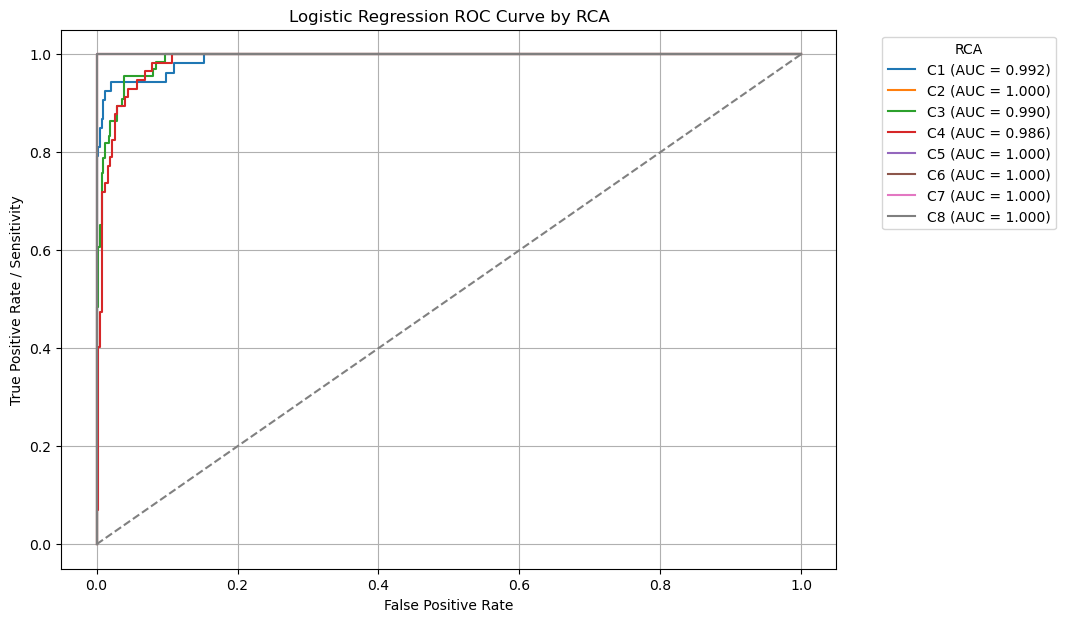

In [47]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Class labels
classes = log_model.classes_

# Binarize y_test for One-vs-Rest ROC
y_test_bin = label_binarize(y_test, classes=classes)

# Predicted probabilities
y_score = probs

plt.figure(figsize=(10, 7))

roc_auc_dict = {}

for i, cls in enumerate(classes):
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)
    roc_auc_dict[cls] = roc_auc

    plt.plot(
        fpr,
        tpr,
        label=f"{cls} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

plt.title("Logistic Regression ROC Curve by RCA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

AUC ≈ 0.99–1.00 for almost every class with baseline Logistic Regression. Which is suspiciously high. There might be data leakage here.


#### LR - Precision-recall curve plot

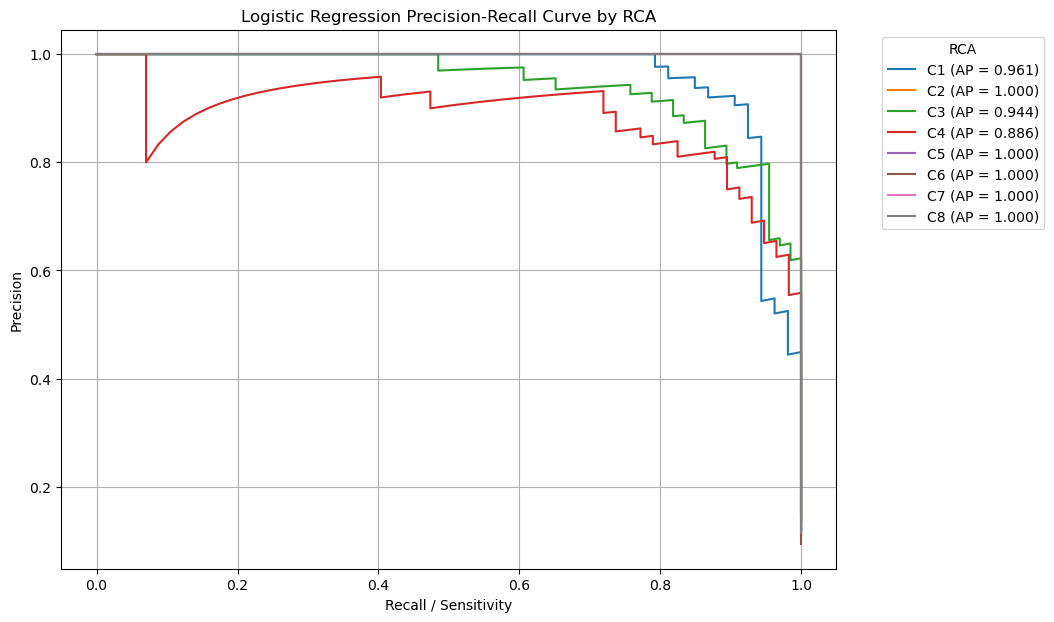

In [48]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))

pr_auc_dict = {}

for i, cls in enumerate(classes):
    precision, recall, thresholds = precision_recall_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    avg_precision = average_precision_score(
        y_test_bin[:, i],
        y_score[:, i]
    )

    pr_auc_dict[cls] = avg_precision

    plt.plot(
        recall,
        precision,
        label=f"{cls} (AP = {avg_precision:.3f})"
    )

plt.title("Logistic Regression Precision-Recall Curve by RCA")
plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

#### Youden's J

In [49]:
from sklearn.metrics import confusion_matrix
import pandas as pd

youden_results = []

for cls in classes:
    # One-vs-rest conversion
    y_true_binary = (y_test == cls).astype(int)
    y_pred_binary = (preds == cls).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true_binary,
        y_pred_binary
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youden_j = sensitivity + specificity - 1

    youden_results.append({
        "RCA": cls,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Youden_J": youden_j
    })

youden_df = pd.DataFrame(youden_results)

display(
    youden_df.sort_values(
        "Youden_J",
        ascending=False
    ).round(3)
)

,RCA,Sensitivity,Specificity,Youden_J
1,C2,1.000,1.000,1.000
4,C5,1.000,1.000,1.000
6,C7,1.000,1.000,1.000
7,C8,1.000,1.000,1.000
5,C6,1.000,0.998,0.998
0,C1,0.868,0.993,0.861
2,C3,0.864,0.973,0.837
3,C4,0.825,0.974,0.799


### LR - Confusion Matrix

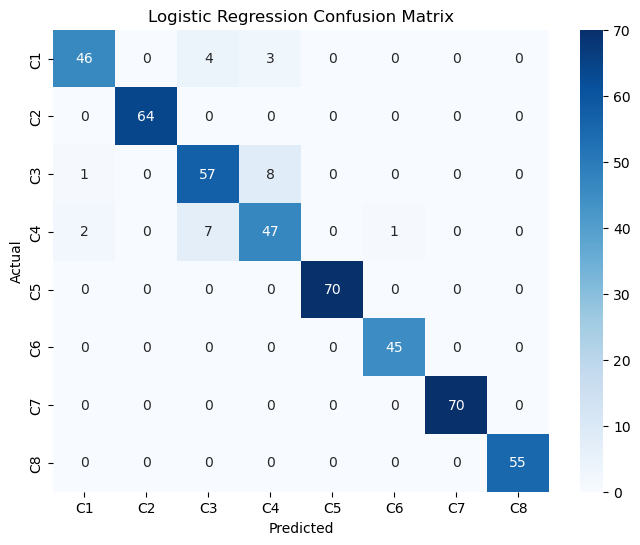

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=log_model.classes_,
    yticklabels=log_model.classes_
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Confusion Matrix Observations – Logistic Regression

* **Overall classification performance was strong**, achieving approximately **94.5% accuracy and macro F1**, suggesting that engineered telecom KPIs effectively distinguish RCA categories.

* **C2 (Coverage Overshooting) was perfectly classified** with **100% precision and recall**, indicating that overshooting scenarios exhibit a highly distinctive KPI signature, particularly through serving distance features.

* **C5 and C7 also achieved near-perfect classification**, suggesting that mobility and handover-related degradation mechanisms are highly separable from other RCA categories.

* **C6 (PCI Conflict) demonstrated excellent performance** (**Precision = 0.98, Recall = 1.00**), supporting the effectiveness of modulo-30 PCI conflict features (`same_mod30_ratio`, `same_mod30_count`) for identifying interference-related RCA.

* **C8 (Resource Insufficiency) was perfectly identified**, reinforcing EDA findings that RB-related features create a distinct degradation pattern.

* **The model struggled most with C1, C3, and C4**, where moderate confusion was observed between categories.

* **C3 and C4 showed the highest overlap**, indicating that neighboring-cell throughput issues and overlapping coverage may exhibit similar telecom KPI behavior, making separation more challenging for a linear model.

* **C1 occasionally overlapped with C3/C4**, suggesting that some tilt-related scenarios may share characteristics with neighboring-cell or overlap-driven degradation.

* Despite a very high **ROC-AUC (~0.996)**, the confusion matrix suggests that some RCA mechanisms remain operationally similar, highlighting opportunities for **nonlinear models (e.g., XGBoost, LightGBM)** to further improve separation among overlapping classes.


### LR - Classification Report

In [51]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

          C1       0.94      0.87      0.90        53
          C2       1.00      1.00      1.00        64
          C3       0.84      0.86      0.85        66
          C4       0.81      0.82      0.82        57
          C5       1.00      1.00      1.00        70
          C6       0.98      1.00      0.99        45
          C7       1.00      1.00      1.00        70
          C8       1.00      1.00      1.00        55

    accuracy                           0.95       480
   macro avg       0.95      0.94      0.94       480
weighted avg       0.95      0.95      0.95       480



### Checking for any data leakage as we are seeing high accuaracy and high RPC and precisions for each classes. 

In [52]:
coef_df = pd.DataFrame(
    log_model.coef_.T,
    index=X_encoded.columns,
    columns=log_model.classes_
)

coef_df.abs().max(axis=1)\
    .sort_values(ascending=False)\
    .head(20)

same_mod30_ratio          1.990677
avg_throughput_low_tp     1.926054
min_throughput            1.876740
same_mod30_count          1.840043
overlap_ratio             1.600369
handover_rate             1.446000
handover_count            1.446000
pct_speed_above_40        1.440052
min_rsrp                  1.160695
avg_neighbor_advantage    1.146384
std_throughput            1.054671
avg_rsrp                  1.043072
handover_count_low_tp     1.020207
avg_speed_low_tp          1.004736
pct_rb_below_160          0.956391
max_speed                 0.946284
avg_serving_tilt          0.927645
avg_serving_height        0.898992
max_speed_low_tp          0.858916
avg_rb_low_tp             0.844756
dtype: float64

Although the Logistic Regression model achieved near-perfect performance, this appears to be a case of **domain-rule leakage rather than traditional data leakage**. Traditional data leakage occurs when information from the target variable or test set is unintentionally exposed to the model during training. In contrast, our engineered features were intentionally derived from domain knowledge and closely reflect the RCA definitions provided in the TeleLogs framework. For example, features such as `same_mod30_ratio`, `overlap_ratio`, `handover_count`, and `pct_rb_below_160` directly correspond to predefined RCA mechanisms such as PCI mod 30 conflict, overlapping coverage, frequent handovers, and insufficient RB allocation. As a result, the model is not memorizing hidden labels or test information, but rather learning structured telecom troubleshooting rules embedded in the feature space. This explains the unusually strong baseline performance and suggests that the model is effectively leveraging engineered telecom expertise to infer root causes.


### LR - Internal CV

Macro-averaged evaluation metrics were used to ensure that all RCA categories contributed equally to model performance, regardless of class frequency. Since the objective of RCA classification is to reliably identify all failure mechanisms rather than favor majority classes, macro averaging provides a more balanced assessment of predictive performance across root causes.

In [53]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# -----------------------------
# X and y
# -----------------------------

X = ml_df.drop("answer", axis=1)
y = ml_df["answer"]

# -----------------------------
# Identify numeric / categorical columns
# -----------------------------

numeric_cols = X.select_dtypes(include=["number"]).columns
categorical_cols = X.select_dtypes(exclude=["number"]).columns

# -----------------------------
# Preprocessing
# -----------------------------

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# -----------------------------
# Logistic Regression model
# -----------------------------

log_model_cv = LogisticRegression(
    multi_class="multinomial",
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

# -----------------------------
# Full pipeline
# -----------------------------

log_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", log_model_cv)
    ]
)

# -----------------------------
# Cross-validation
# -----------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc_ovr": "roc_auc_ovr"
}

cv_results = cross_validate(
    log_pipeline,
    X,
    y,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

# -----------------------------
# Results summary
# -----------------------------

for metric in scoring.keys():
    test_scores = cv_results[f"test_{metric}"]
    train_scores = cv_results[f"train_{metric}"]

    print(f"{metric}")
    print(f"  Train: {np.mean(train_scores):.3f} ({np.std(train_scores):.3f})")
    print(f"  Test : {np.mean(test_scores):.3f} ({np.std(test_scores):.3f})")
    print("-" * 40)

accuracy
  Train: 0.958 (0.002)
  Test : 0.943 (0.007)
----------------------------------------
precision_macro
  Train: 0.957 (0.002)
  Test : 0.943 (0.007)
----------------------------------------
recall_macro
  Train: 0.958 (0.002)
  Test : 0.942 (0.007)
----------------------------------------
f1_macro
  Train: 0.957 (0.002)
  Test : 0.942 (0.007)
----------------------------------------
roc_auc_ovr
  Train: 0.997 (0.000)
  Test : 0.995 (0.001)
----------------------------------------


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in ve

| Metric          | Train |  Test |
| --------------- | ----: | ----: |
| Accuracy        | 0.958 | 0.943 |
| Precision Macro | 0.957 | 0.943 |
| Recall Macro    | 0.958 | 0.942 |
| F1 Macro        | 0.957 | 0.942 |
| ROC-AUC         | 0.997 | 0.995 |


**Logistic Regression Baseline**

Even a simple interpretable model achieved:

94.5% F1
99.6% ROC-AUC

suggesting:

**telecom RCA mechanisms are strongly explainable through engineered KPIs.**

However:

C3/C4/C1

showed higher confusion due to overlapping telecom behavior.

While:

C2/C5/C6/C7/C8

were highly distinguishable.

#### Assumption check
##### 1. Multicolinearity

In [54]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# numeric only
X_num = X_encoded.select_dtypes(include=np.number)

vif_df = pd.DataFrame()
vif_df["Feature"] = X_num.columns

vif_df["VIF"] = [
    variance_inflation_factor(
        X_num.values, i
    )
    for i in range(X_num.shape[1])
]

vif_df = vif_df.sort_values(
    "VIF",
    ascending=False
)

vif_df.head(50)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
13,handover_rate,inf
3,low_tp_count,inf
4,low_tp_ratio,inf
12,handover_count,inf
11,num_unique_serving_pci,8487.133050
42,max_serving_distance_km,646.437402
44,avg_distance_low_tp,501.597096
43,pct_distance_gt_1km,310.786747
26,avg_rb_low_tp,244.644421
41,avg_serving_distance_km,106.346091


Variance Inflation Factor (VIF) analysis revealed substantial multicollinearity among engineered telecom features, particularly within groups describing similar network behaviors (e.g., handover activity, SINR quality, serving distance, RB allocation, and low-throughput periods). Several variables exhibited extremely high or infinite VIF values due to mathematical dependence or strong conceptual overlap (e.g., `handover_count` and `handover_rate`, `low_tp_count` and `low_tp_ratio`). While multicollinearity may reduce coefficient interpretability in Logistic Regression, it is less problematic for predictive performance, as reflected by stable internal cross-validation results. Since the primary objective of this study is RCA prediction rather than coefficient inference, correlated telecom KPIs were retained to preserve domain-relevant signal for downstream machine learning models.


#### 2. Linear relationship with log-odds

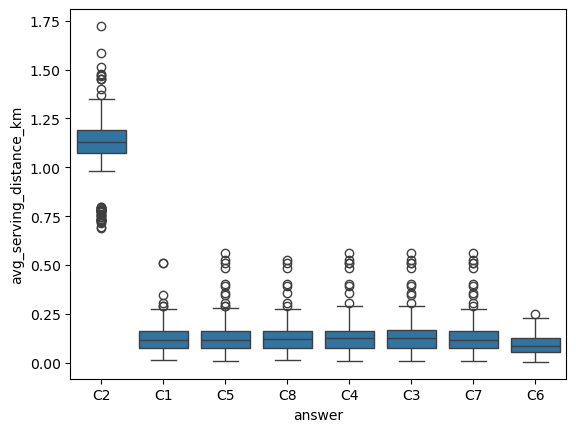

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=ml_df,
    x="answer",
    y="avg_serving_distance_km"
)

plt.show()

#### 3. No extreme class imbalance

#### 4. Independence of observations ⚠️
We will assume that each observation is independent to each other.

#### 5. Any outliers

In [56]:
X_encoded.describe().T[
    ["min","25%","50%","75%","max"]
]

,min,25%,50%,75%,max
avg_throughput,504.807000,640.596000,711.197000,819.266000,1197.858000
min_throughput,0.000000,190.530000,273.540000,374.910000,665.300000
std_throughput,180.387110,302.501276,355.970841,409.940624,607.363614
low_tp_count,0.000000,4.000000,4.000000,4.000000,4.000000
low_tp_ratio,0.000000,0.400000,0.400000,0.400000,0.400000
avg_throughput_low_tp,45.830000,263.658125,340.105000,431.155000,593.750000
consecutive_low_tp_max,0.000000,4.000000,4.000000,4.000000,4.000000
max_speed,22.000000,35.000000,37.000000,39.000000,79.000000
pct_speed_above_40,0.000000,0.000000,0.000000,0.000000,0.400000
avg_speed_low_tp,2.000000,16.000000,20.750000,26.500000,77.250000


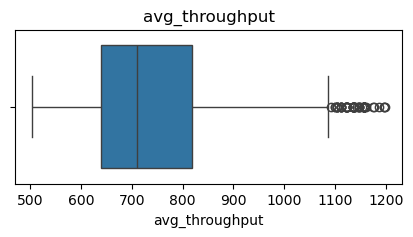

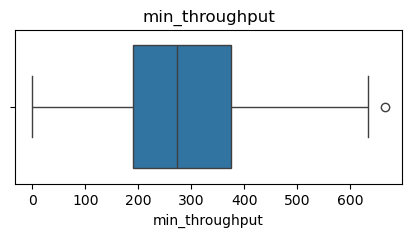

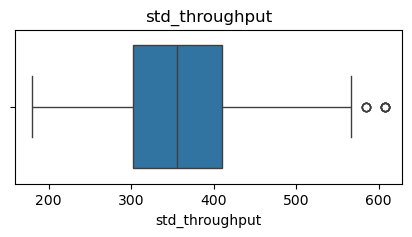

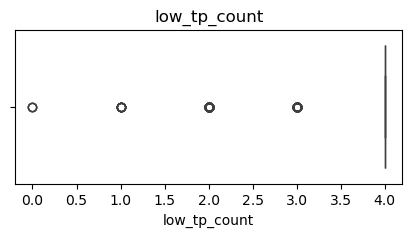

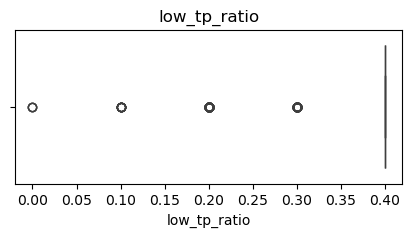

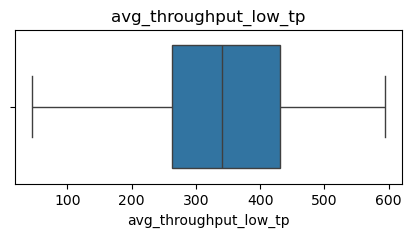

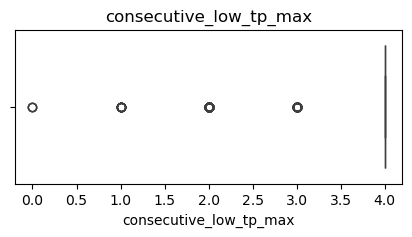

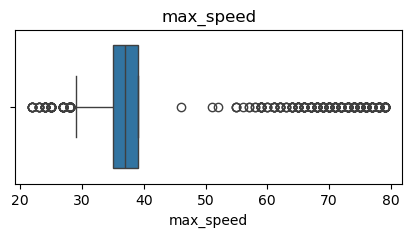

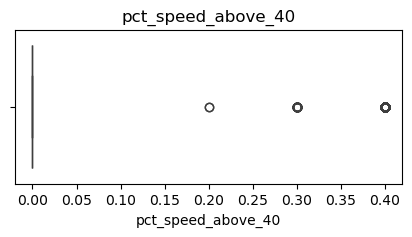

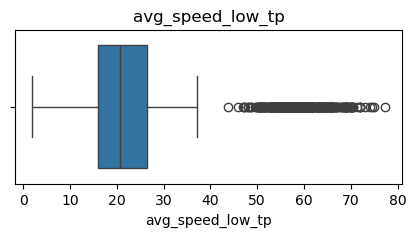

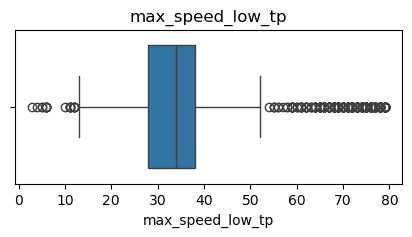

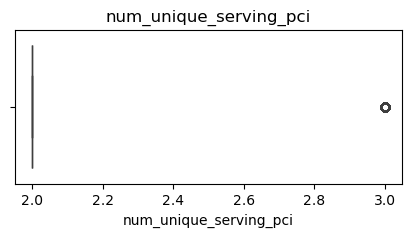

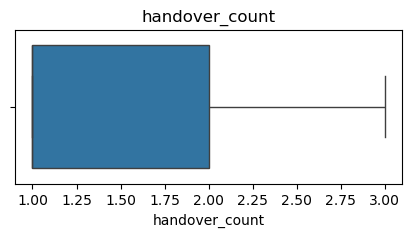

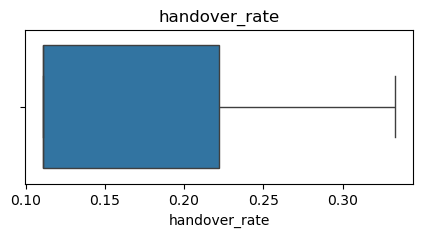

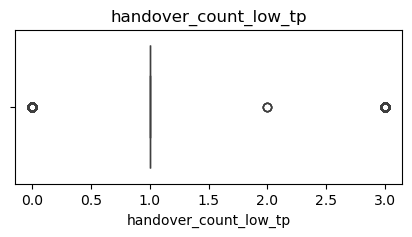

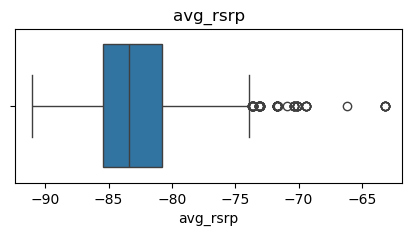

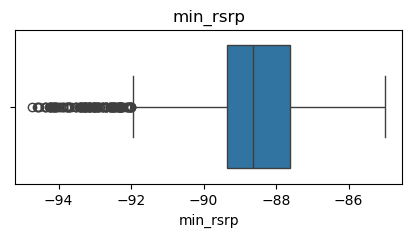

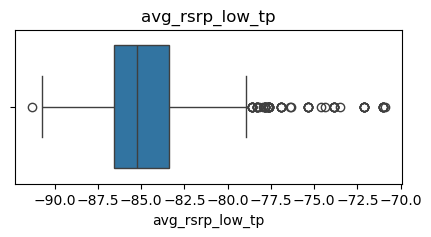

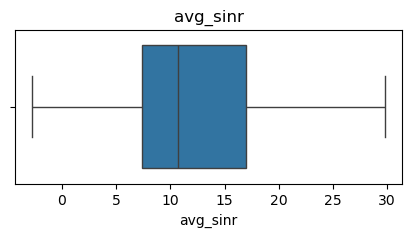

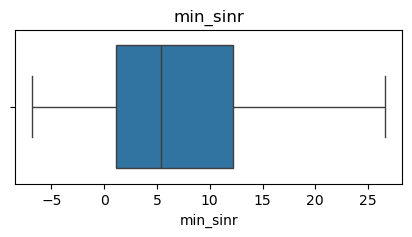

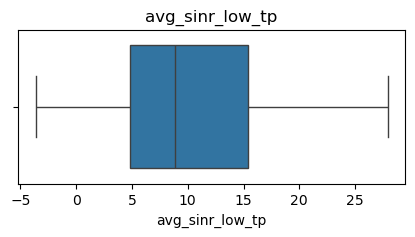

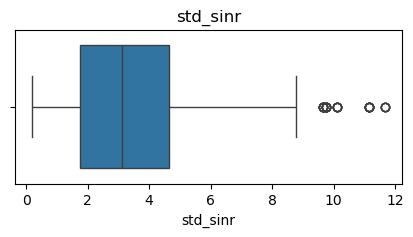

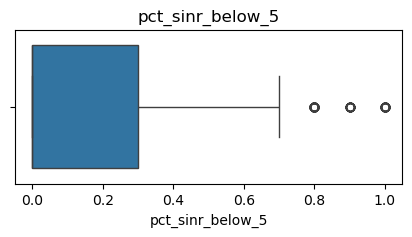

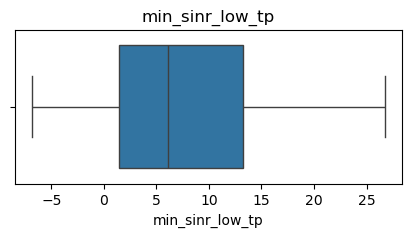

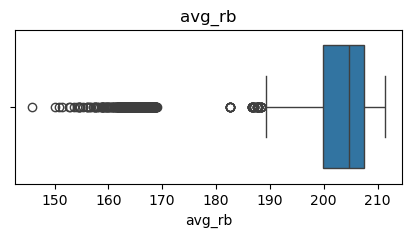

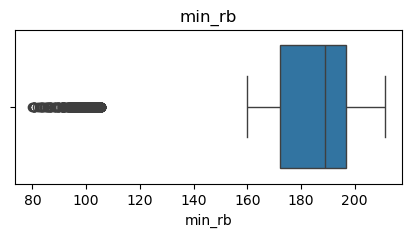

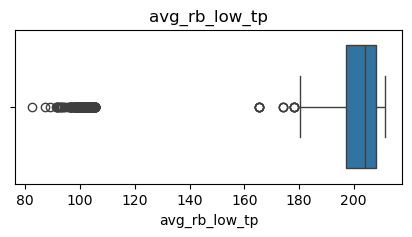

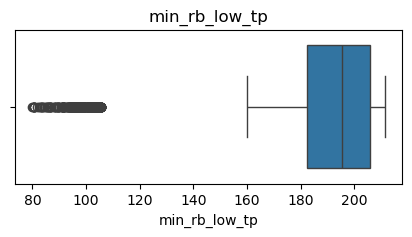

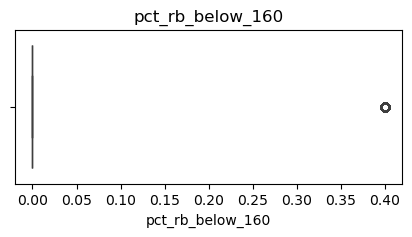

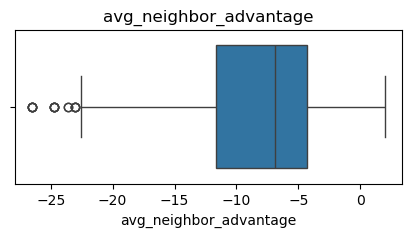

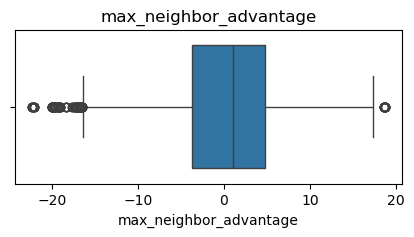

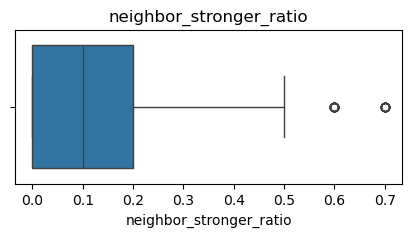

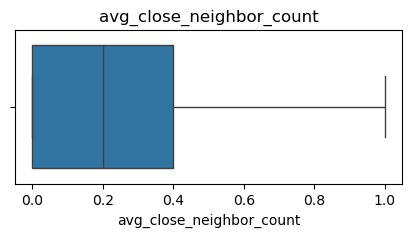

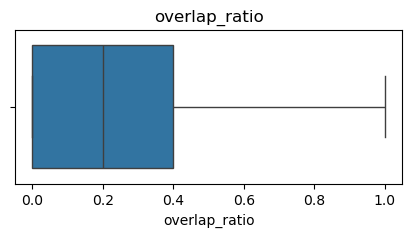

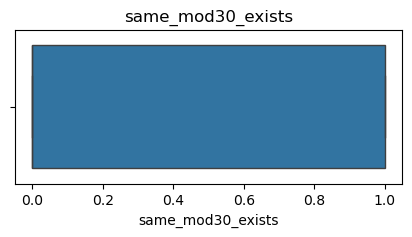

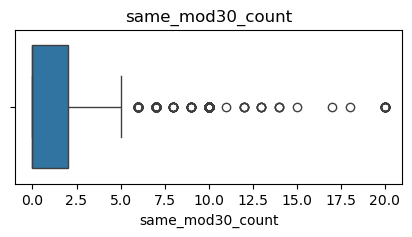

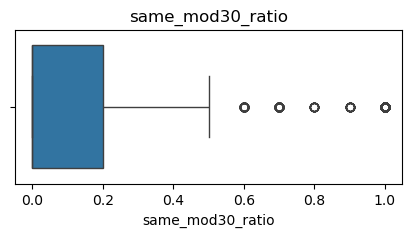

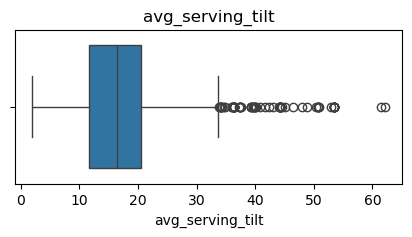

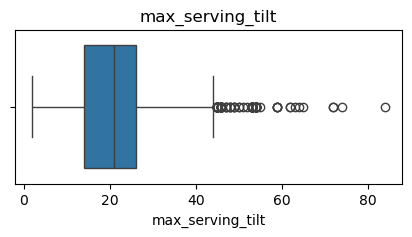

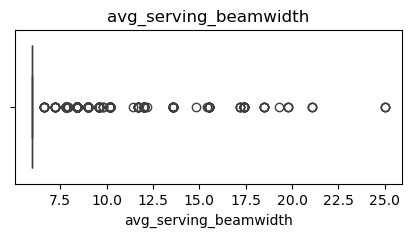

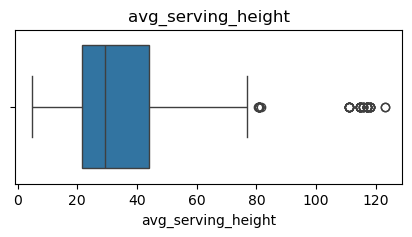

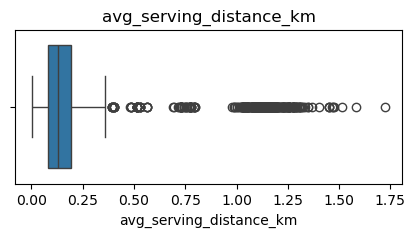

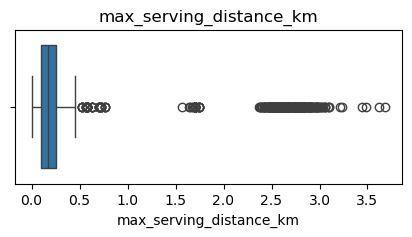

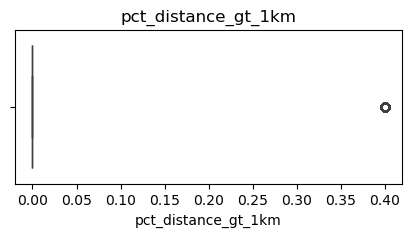

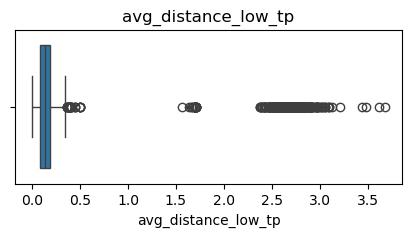

In [57]:
for col in numeric_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=ml_df[col])
    plt.title(col)
    plt.show()

Descriptive statistics did not indicate substantial extreme outliers that would likely distort Logistic Regression performance. Although some variables exhibited wider ranges (e.g., serving distance and PCI-related features), these observations reflect meaningful telecom behaviors associated with RCA mechanisms (e.g., coverage overshooting or PCI conflict) rather than data quality issues. Therefore, potentially extreme values were retained to preserve operational signal relevant for root cause classification.


### External Cross Validation with test data set

In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# -----------------------------
# Refit Logistic Regression on FULL train.json
# -----------------------------

# X_encoded and y should come from full train.json
X_full_train = X_encoded.copy()
y_full_train = y.copy()

# Scale using FULL train.json only
scaler = StandardScaler()

X_full_train_scaled = scaler.fit_transform(
    X_full_train
)

# Refit final Logistic Regression model
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42,
    solver="lbfgs"
)

log_model.fit(
    X_full_train_scaled,
    y_full_train
)

print("Final Logistic Regression model refit on 100% of train.json")
print("Training shape:", X_full_train.shape)

import json
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load external test.json
with open("../data/test.json", "r") as f:
    test = json.load(f)

# 2. Apply same feature engineering used for train.json
test_rows = []

for item in test:
    user_df, eng_df = parse_tables(item["question"])
    features = make_features(user_df, eng_df)
    features["answer"] = item["answer"]
    test_rows.append(features)

test_df = pd.DataFrame(test_rows)

print("External test shape:", test_df.shape)
print(test_df.head())

# 3. Separate predictors and target
X_test_external = test_df.drop(columns=["answer"])
y_test_external = test_df["answer"]

# 4. One-hot encode categorical variables
X_test_external = pd.get_dummies(
    X_test_external,
    drop_first=True
)

# 5. Match training columns exactly
X_test_external = X_test_external.reindex(
    columns=X_train.columns,
    fill_value=0
)

# 6. Convert all columns to numeric just in case
X_test_external = X_test_external.apply(
    pd.to_numeric,
    errors="coerce"
)

# 7. Impute missing values using TRAINING medians
X_test_external = X_test_external.fillna(
    X_train.median()
)

# 8. Safety checks
print("Column match:", X_test_external.columns.equals(X_train.columns))
print("Remaining missing values:", X_test_external.isna().sum().sum())
print("Non-numeric columns:",
      X_test_external.select_dtypes(include=["object", "category"]).columns.tolist())

# Scale external test set using the SAME scaler fitted on X_train
X_test_external_scaled = scaler.transform(X_test_external)

# Predict
external_preds = log_model.predict(X_test_external_scaled)

# 10. Evaluation
print("\nExternal Test Accuracy:")
print(accuracy_score(y_test_external, external_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_external, external_preds))

print("\nClassification Report:")
print(classification_report(y_test_external, external_preds))

Final Logistic Regression model refit on 100% of train.json
Training shape: (2400, 48)


/var/folders/d2/c8fwz9l96rl39_vj0tf9cbyw0000gn/T/ipykernel_15238/1489184309.py:95: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  user_df = user_df.copy().replace("-", np.nan)
/var/folders/d2/c8fwz9l96rl39_vj0tf9cbyw0000gn/T/ipykernel_15238/1489184309.py:95: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  user_df = user_df.copy().replace("-", np.nan)
/var/folders/d2/c8fwz9l96rl39_vj0tf9cbyw0000gn/T/ipykernel_15238/1489184309.py:95: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version.

External test shape: (864, 48)
   avg_throughput  min_throughput  std_throughput  low_tp_count  low_tp_ratio  \
0         642.122            0.14      480.631072             4           0.4   
1         642.122            0.14      480.631072             4           0.4   
2         682.122            0.14      448.967513             4           0.4   
3         642.122            0.14      480.631072             4           0.4   
4         642.122            0.14      480.631072             4           0.4   

   avg_throughput_low_tp  consecutive_low_tp_max  max_speed  \
0                118.835                       4         38   
1                118.835                       4         38   
2                218.835                       4         38   
3                118.835                       4         38   
4                118.835                       4         38   

   pct_speed_above_40  avg_speed_low_tp  ...  antenna_model  avg_serving_tilt  \
0                 0.0 

In [59]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

# Classification report as dictionary
report = classification_report(
    y_test_external,
    external_preds,
    output_dict=True
)

# Convert to dataframe
metrics_df = pd.DataFrame(report).transpose()

# Add overall accuracy
metrics_df.loc["accuracy", "precision"] = accuracy_score(
    y_test_external,
    external_preds
)

# Round values
metrics_df = metrics_df.round(3)

metrics_df

summary_metrics = pd.DataFrame({
    "Metric": [
        "External Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1 Score",
        "Weighted F1 Score"
    ],
    "Value": [
        accuracy_score(y_test_external, external_preds),
        report["macro avg"]["precision"],
        report["macro avg"]["recall"],
        report["macro avg"]["f1-score"],
        report["weighted avg"]["f1-score"]
    ]
})

summary_metrics = summary_metrics.round(3)
summary_metrics

,Metric,Value
0,External Accuracy,0.936
1,Macro Precision,0.941
2,Macro Recall,0.936
3,Macro F1 Score,0.936
4,Weighted F1 Score,0.936


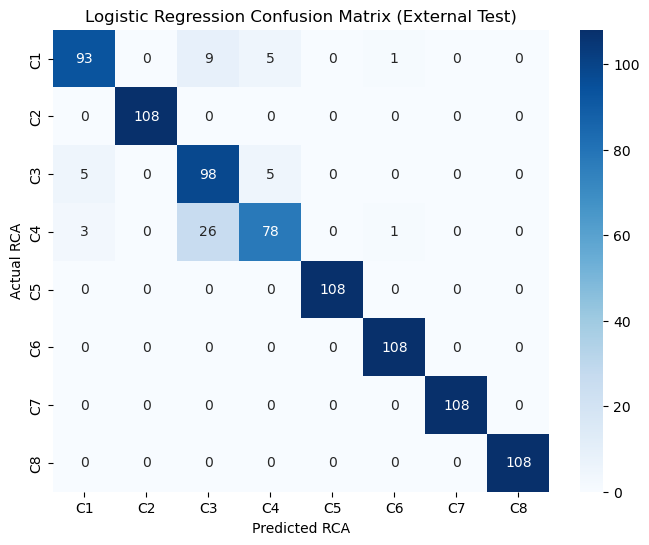

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Confusion Matrix
# -----------------------------

cm = confusion_matrix(
    y_test_external,
    external_preds,
    labels=log_model.classes_
)

# -----------------------------
# Plot Heatmap
# -----------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=log_model.classes_,
    yticklabels=log_model.classes_
)

plt.title(
    "Logistic Regression Confusion Matrix (External Test)"
)

plt.xlabel("Predicted RCA")
plt.ylabel("Actual RCA")

plt.show()

## 2. Random Forest
### Grid Search

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

param_grid = {
    "n_estimators": [110,120,125,129, 130,131,135],
    "max_depth": [12,13,14],
    "min_samples_leaf": [4],
    "max_features": ["sqrt", None]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 42 candidates, totalling 210 fits
[CV] END max_depth=12, max_features=sqrt, min_samples_leaf=4, n_estimators=110; total time=   0.2s
[CV] END max_depth=12, max_features=sqrt, min_samples_leaf=4, n_estimators=110; total time=   0.2s
[CV] END max_depth=12, max_features=sqrt, min_samples_leaf=4, n_estimators=110; total time=   0.2s
[CV] END max_depth=12, max_features=sqrt, min_samples_leaf=4, n_estimators=120; total time=   0.2s
[CV] END max_depth=12, max_features=sqrt, min_samples_leaf=4, n_estimators=120; total time=   0.2s
[CV] END max_depth=12, max_features=sqrt, min_samples_leaf=4, n_estimators=125; total time=   0.2s
[CV] END max_depth=12, max_features=sqrt, min_samples_leaf=4, n_estimators=129; total time=   0.3s
[CV] END max_depth=12, max_features=sqrt, min_samples_leaf=4, n_estimators=129; total time=   0.3s
[CV] END max_depth=12, max_features=sqrt, min_samples_leaf=4, n_estimators=129; total time=   0.3s
[CV] END max_depth=12, max_features=sqrt, min_s

{'max_depth': 13, 'max_features': None, 'min_samples_leaf': 4, 'n_estimators': 125}

Best CV Score:
0.9428803016010336

- max_features: how many features the model is allowed to consider at each split of a tree
    - sqrt: if there are 50 features, every time it seas around square root of 50 which is around 7 features. 



Grid Search identified the optimal Random Forest hyperparameters as **125 trees (`n_estimators=125`)**, **maximum tree depth of 13 (`max_depth=13`)**, **minimum leaf size of 4 (`min_samples_leaf=4`)**, and **all features considered at each split (`max_features=None`)**. The selected parameters suggest that RCA classification benefits from moderately complex nonlinear decision boundaries while maintaining regularization through minimum leaf constraints. Interestingly, allowing all features at each split yielded the best performance, indicating that telecom RCA prediction benefits from jointly considering multiple engineered KPIs rather than relying on small random feature subsets.


### Fit Random Forest

In [62]:
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(
    n_estimators=125,
    max_depth=13,
    max_features=None,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

rf_preds = best_rf.predict(X_test)
rf_probs = best_rf.predict_proba(X_test)

### RF - Evaluation Metrics

In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

rf_accuracy = accuracy_score(y_test, rf_preds)

rf_precision = precision_score(
    y_test,
    rf_preds,
    average="macro"
)

rf_recall = recall_score(
    y_test,
    rf_preds,
    average="macro"
)

rf_f1 = f1_score(
    y_test,
    rf_preds,
    average="macro"
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_probs,
    multi_class="ovr",
    average="macro"
)

print("Random Forest Results")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)
print("ROC-AUC:", rf_roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

Random Forest Results
Accuracy: 0.94375
Precision: 0.9462037037037037
Recall: 0.9427868556468357
F1: 0.9441305488688351
ROC-AUC: 0.9964672537402648

Classification Report:
              precision    recall  f1-score   support

          C1       0.94      0.89      0.91        53
          C2       1.00      1.00      1.00        64
          C3       0.78      0.85      0.81        66
          C4       0.85      0.81      0.83        57
          C5       1.00      1.00      1.00        70
          C6       1.00      1.00      1.00        45
          C7       1.00      1.00      1.00        70
          C8       1.00      1.00      1.00        55

    accuracy                           0.94       480
   macro avg       0.95      0.94      0.94       480
weighted avg       0.95      0.94      0.94       480



### 3. RF - Confusion Matrix

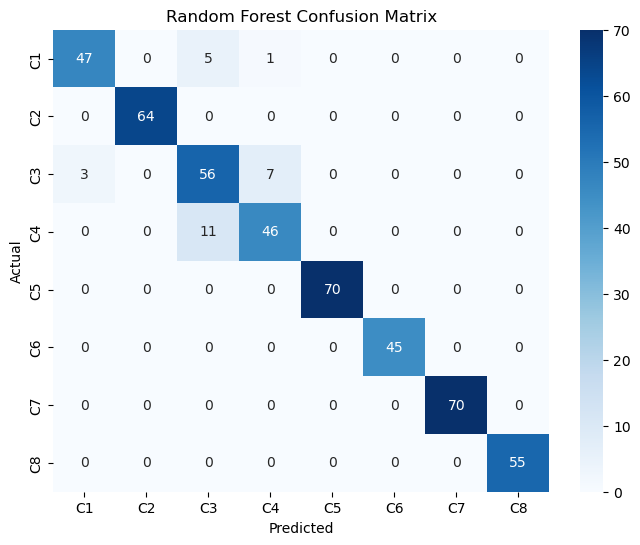

In [64]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf_cm = confusion_matrix(
    y_test,
    rf_preds,
    labels=best_rf.classes_
)

plt.figure(figsize=(8,6))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_rf.classes_,
    yticklabels=best_rf.classes_
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [65]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

rf_youden_results = []

for cls in best_rf.classes_:
    y_true_binary = (y_test == cls).astype(int)
    y_pred_binary = (rf_preds == cls).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true_binary,
        y_pred_binary
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youden_j = sensitivity + specificity - 1

    rf_youden_results.append({
        "RCA": cls,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Youden_J": youden_j
    })

rf_youden_df = pd.DataFrame(rf_youden_results)

display(
    rf_youden_df.sort_values(
        "Youden_J",
        ascending=False
    ).round(3)
)

,RCA,Sensitivity,Specificity,Youden_J
1,C2,1.000,1.000,1.000
4,C5,1.000,1.000,1.000
5,C6,1.000,1.000,1.000
6,C7,1.000,1.000,1.000
7,C8,1.000,1.000,1.000
0,C1,0.887,0.993,0.880
2,C3,0.848,0.961,0.810
3,C4,0.807,0.981,0.788


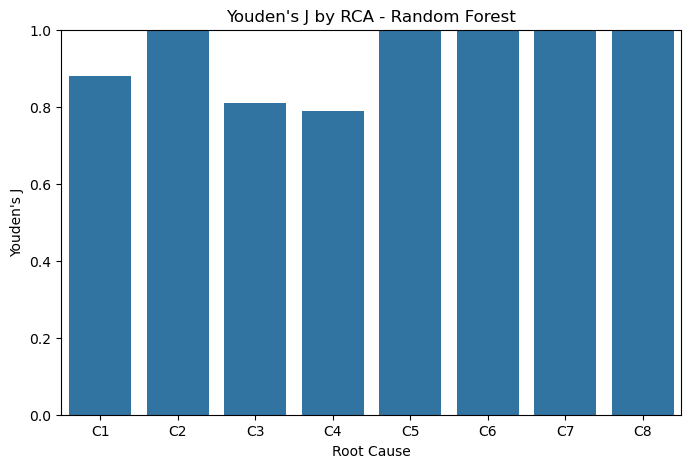

In [66]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=rf_youden_df,
    x="RCA",
    y="Youden_J",
    order=best_rf.classes_
)

plt.title("Youden's J by RCA - Random Forest")
plt.xlabel("Root Cause")
plt.ylabel("Youden's J")
plt.ylim(0, 1)

plt.show()

### RF - Feature importances

In [67]:
rf_feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf.feature_importances_
})

rf_feature_importance = rf_feature_importance.sort_values(
    "importance",
    ascending=False
)

display(rf_feature_importance.head(20))

,feature,importance
28,pct_rb_below_160,0.148854
16,min_rsrp,0.098934
8,pct_speed_above_40,0.093057
12,handover_count,0.085670
36,same_mod30_ratio,0.081494
35,same_mod30_count,0.067454
13,handover_rate,0.066383
7,max_speed,0.040647
42,max_serving_distance_km,0.034796
32,avg_close_neighbor_count,0.033981


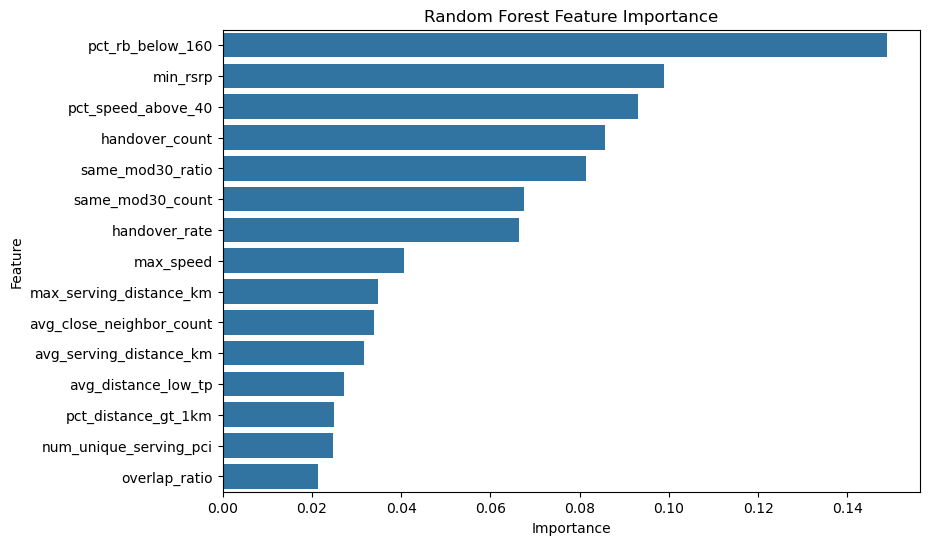

In [68]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=rf_feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

- `pct_speed_above_40`: mobility dynamics strongly contribute to RCA differentiation.
- `min_rsrp` : Strongest radio quality signal.
- `pct_rb_below_160` : resource limitation

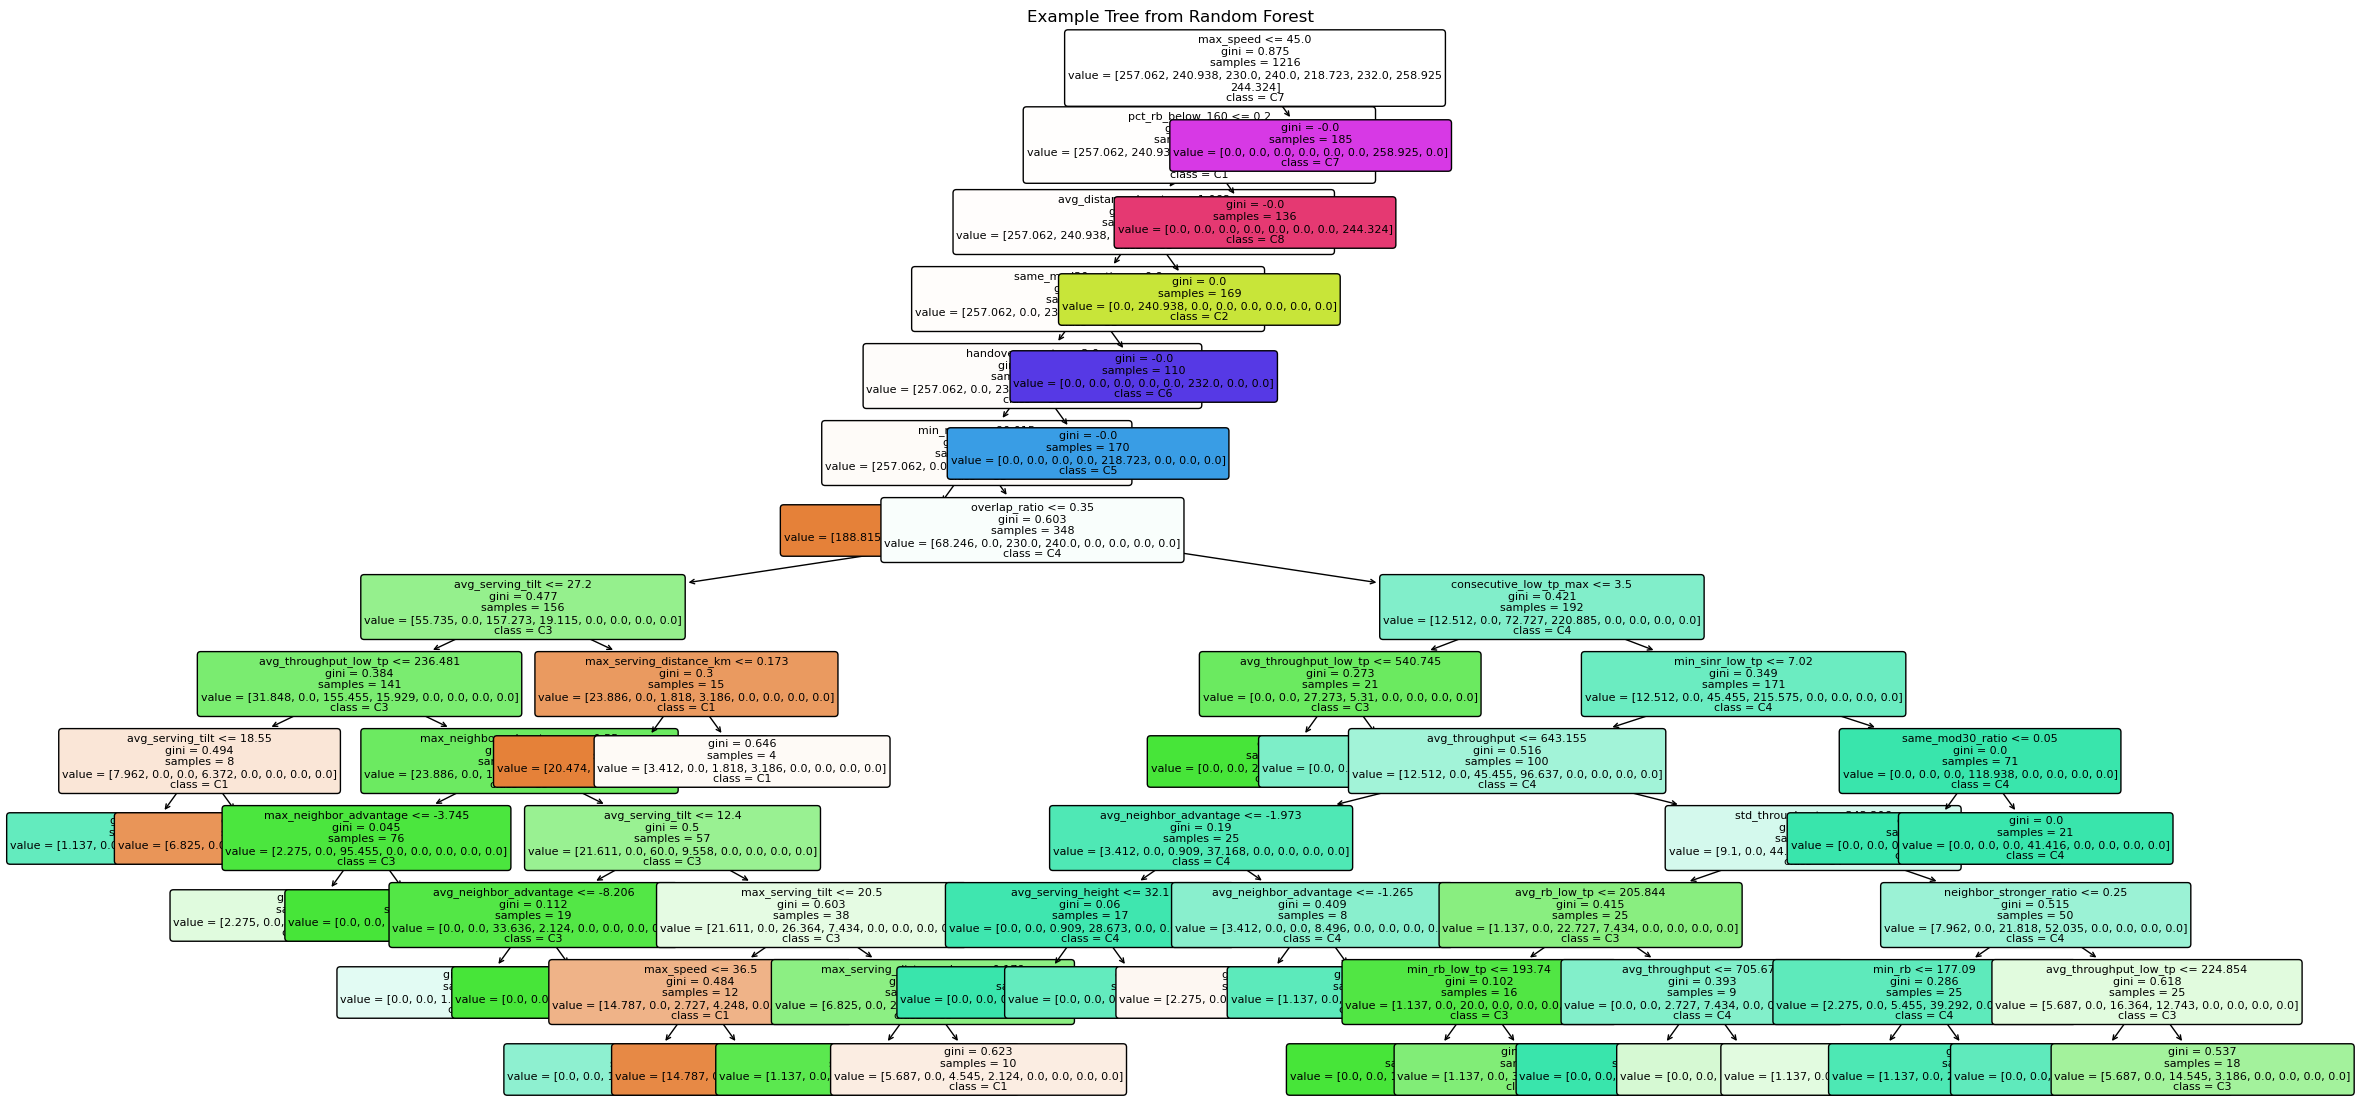

In [69]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(28,14))

plot_tree(
    best_rf.estimators_[0],
    feature_names=X_train.columns,
    class_names=best_rf.classes_,
    filled=True,
    rounded=True,
    max_depth=13,
    fontsize=8
)

plt.title("Example Tree from Random Forest ")
plt.show()

Early splits

```
pct_rb_below_160
same_mod30_ratio
handover_count
serving_distance
```

domain-informed ML.

### RF - ROC curve

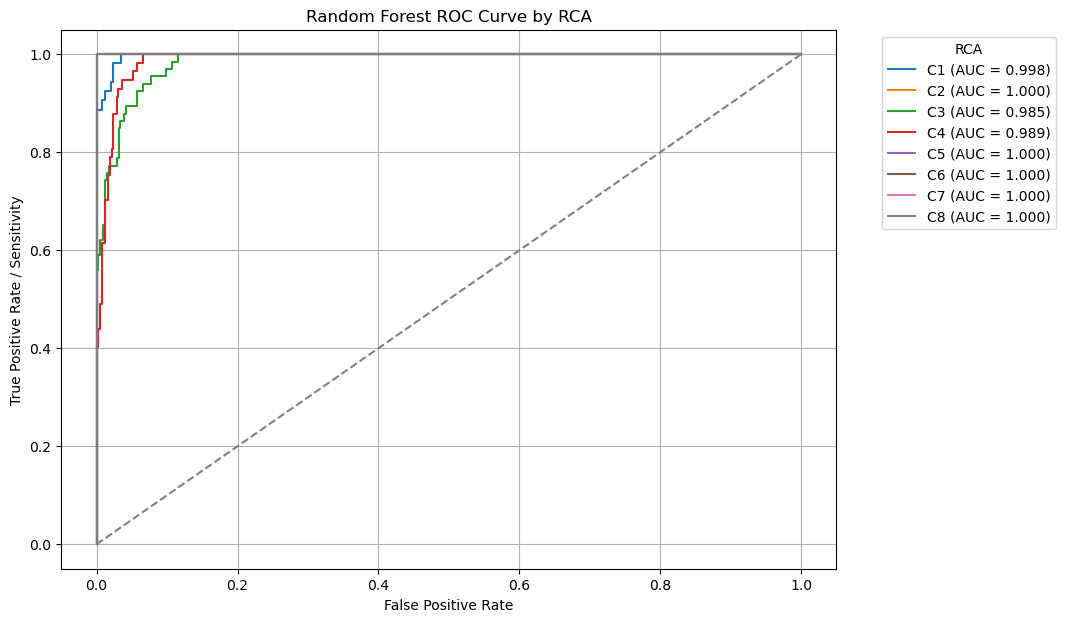

In [70]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

classes = best_rf.classes_

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

plt.figure(figsize=(10,7))

rf_roc_auc_dict = {}

for i, cls in enumerate(classes):
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        rf_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)
    rf_roc_auc_dict[cls] = roc_auc

    plt.plot(
        fpr,
        tpr,
        label=f"{cls} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

plt.title("Random Forest ROC Curve by RCA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

plt.show()

### RF - Precision-Recall Curve — Multiclass One-vs-Rest

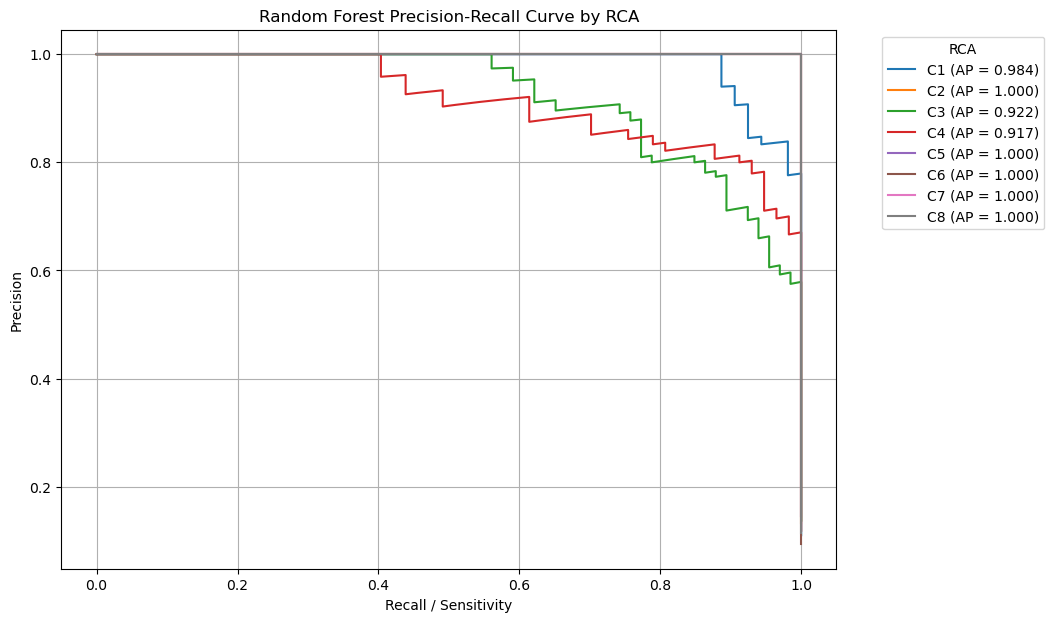

In [71]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10,7))

rf_pr_auc_dict = {}

for i, cls in enumerate(classes):
    precision, recall, thresholds = precision_recall_curve(
        y_test_bin[:, i],
        rf_probs[:, i]
    )

    avg_precision = average_precision_score(
        y_test_bin[:, i],
        rf_probs[:, i]
    )

    rf_pr_auc_dict[cls] = avg_precision

    plt.plot(
        recall,
        precision,
        label=f"{cls} (AP = {avg_precision:.3f})"
    )

plt.title("Random Forest Precision-Recall Curve by RCA")
plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

plt.show()

### RF - Internal 5-Fold CV 

In [72]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

rf_cv_model = RandomForestClassifier(
    n_estimators=125,
    max_depth=13,
    max_features=None,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc_ovr": "roc_auc_ovr"
}

rf_cv_results = cross_validate(
    rf_cv_model,
    X_encoded,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True
)

for metric in scoring.keys():
    train_scores = rf_cv_results[f"train_{metric}"]
    test_scores = rf_cv_results[f"test_{metric}"]

    print(metric)
    print(f"  Train: {np.mean(train_scores):.3f} ({np.std(train_scores):.3f})")
    print(f"  Test : {np.mean(test_scores):.3f} ({np.std(test_scores):.3f})")
    print("-" * 40)

accuracy
  Train: 0.983 (0.001)
  Test : 0.943 (0.006)
----------------------------------------
precision_macro
  Train: 0.983 (0.001)
  Test : 0.944 (0.006)
----------------------------------------
recall_macro
  Train: 0.982 (0.001)
  Test : 0.943 (0.006)
----------------------------------------
f1_macro
  Train: 0.982 (0.001)
  Test : 0.943 (0.006)
----------------------------------------
roc_auc_ovr
  Train: 1.000 (0.000)
  Test : 0.996 (0.000)
----------------------------------------


In [73]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# X and y
# -----------------------------
X = ml_df.drop("answer", axis=1)
y = ml_df["answer"]

# -----------------------------
# Numeric / categorical columns
# -----------------------------
numeric_cols = X.select_dtypes(include=["number"]).columns
categorical_cols = X.select_dtypes(exclude=["number"]).columns

# -----------------------------
# Preprocessing
# -----------------------------
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# -----------------------------
# Random Forest model
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=125,
    max_depth=13,
    max_features=None,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# -----------------------------
# Full pipeline
# -----------------------------
rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", rf_model)
    ]
)

# -----------------------------
# Internal CV
# -----------------------------
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc_ovr": "roc_auc_ovr"
}

rf_cv_results = cross_validate(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True
)

# -----------------------------
# CV Results
# -----------------------------
for metric in scoring.keys():
    train_scores = rf_cv_results[f"train_{metric}"]
    test_scores = rf_cv_results[f"test_{metric}"]

    print(metric)
    print(f"  Train: {np.mean(train_scores):.3f} ({np.std(train_scores):.3f})")
    print(f"  Test : {np.mean(test_scores):.3f} ({np.std(test_scores):.3f})")
    print("-" * 40)

accuracy
  Train: 0.983 (0.001)
  Test : 0.944 (0.006)
----------------------------------------
precision_macro
  Train: 0.983 (0.001)
  Test : 0.945 (0.006)
----------------------------------------
recall_macro
  Train: 0.982 (0.001)
  Test : 0.943 (0.006)
----------------------------------------
f1_macro
  Train: 0.982 (0.001)
  Test : 0.943 (0.006)
----------------------------------------
roc_auc_ovr
  Train: 1.000 (0.000)
  Test : 0.996 (0.000)
----------------------------------------


### Intepretation

#### Random Forest did NOT outperform Logistic Regression.
Engineered telecom features are so informative that even a linear model performs extremely well.

- Logistic Regression
    - Simple
    - Highly interpretable
    - Best macro F1
    - Strong generalization
- Random Forest
    - Slightly more complex
    - Mild overfitting
    - Similar performance
    - Validated telecom feature engineering


Increasing model complexity provided minimal improvement, suggesting that the engineered telecom KPIs already capture the majority of RCA signal.

### SHAP Intepretation

In [74]:
!pip install shap

  Using cached numpy-2.4.6-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached numpy-2.0.2-cp312-cp312-macosx_14_0_arm64.whl.metadata (60 kB)
Using cached numpy-2.0.2-cp312-cp312-macosx_14_0_arm64.whl (5.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.0 which is incompatible.
streamlit 1.37.1 requires rich<14,>=10.14.0, but you have rich 15.0.0 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To upda

In [75]:
import shap

explainer = shap.TreeExplainer(best_rf)

shap_values = explainer.shap_values(X_test)

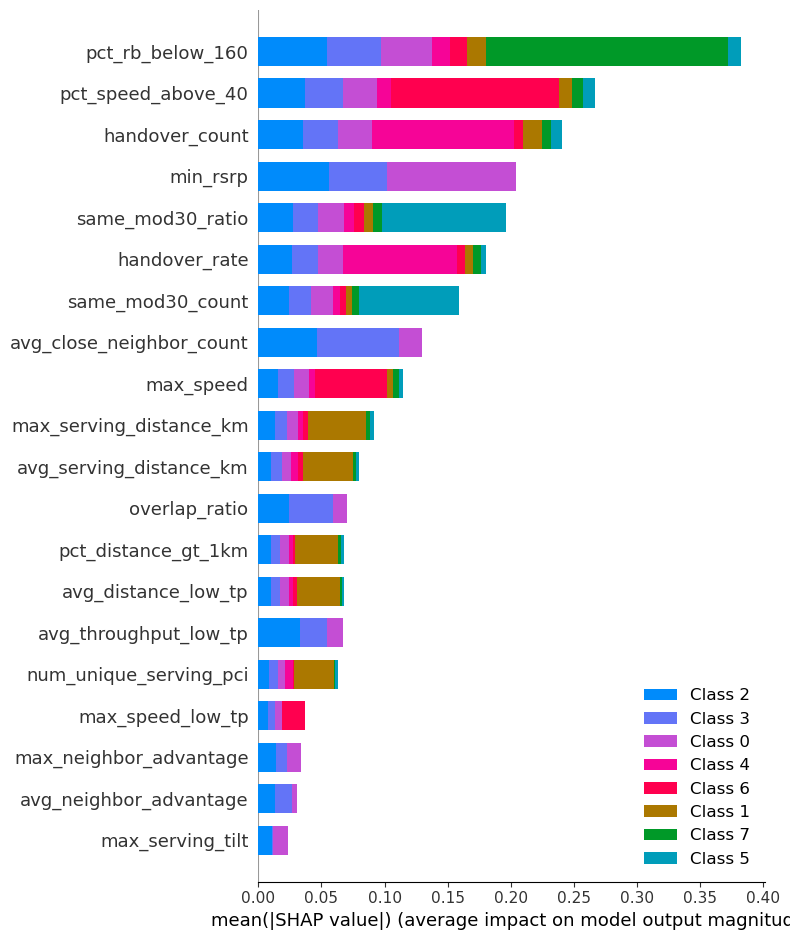

In [76]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

- pct_rb_below_160 is the strongest predictor
    - network resource pressure is globally predictive of failure modes.
- mobility dynamics strongly contribute to RCA differentiation.
    ```
    pct_speed_above_40
    handover_count
    handover_rate
    max_speed
    ```
- PCI conflict features were highly valuable
    - We engineered these features and model is heavily relies on them.

- Distance-based features matter strongly
    - overshooting-related RCA is strongly distance driven.
- Neighbor / overlap features matter, but less than expected

Global SHAP analysis revealed that RCA classification was primarily driven by engineered telecom KPIs related to resource availability, mobility, PCI conflict, and serving distance. The most influential feature was pct_rb_below_160, suggesting that radio resource scarcity plays a major role in distinguishing degradation mechanisms. Mobility-related variables (pct_speed_above_40, handover_count, handover_rate) and engineered PCI conflict indicators (same_mod30_ratio, same_mod30_count) also contributed strongly, validating the domain-informed feature engineering strategy. Interestingly, contextual network indicators were more influential than throughput alone, suggesting that RCA identification depends not only on performance degradation itself, but also on the surrounding radio and mobility conditions that drive it.

In [77]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("List length:", len(shap_values))
    print("Shape of first item:", shap_values[0].shape)
else:
    print("Shape:", shap_values.shape)

print("X_test shape:", X_test.shape)
print(best_rf.classes_)

<class 'numpy.ndarray'>
Shape: (480, 48, 8)
X_test shape: (480, 48)
['C1' 'C2' 'C3' 'C4' 'C5' 'C6' 'C7' 'C8']


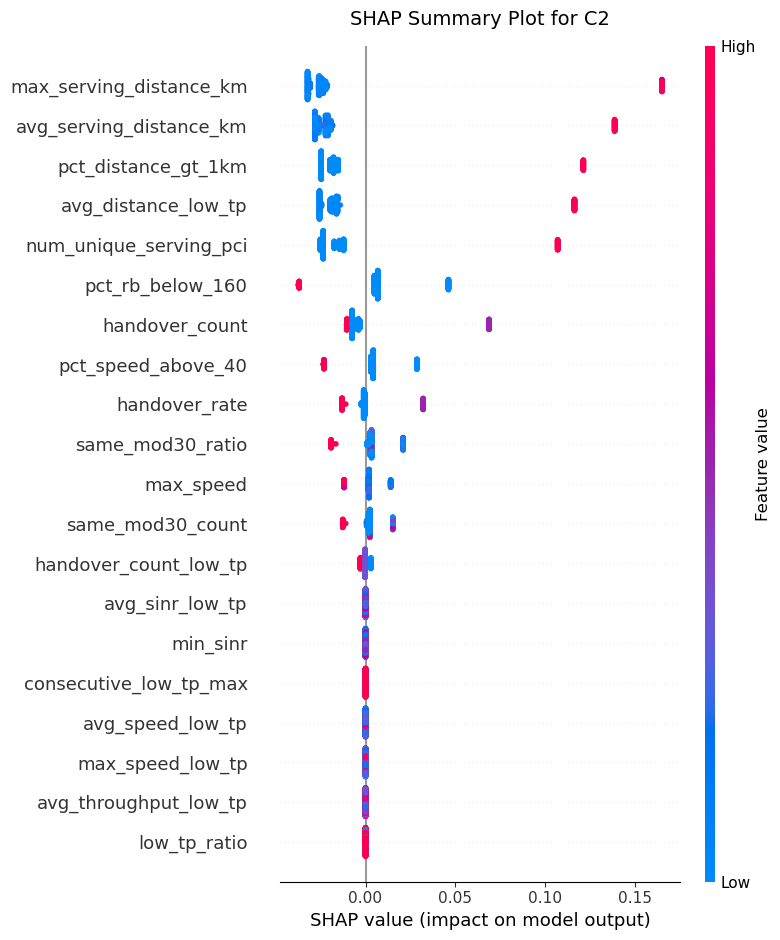

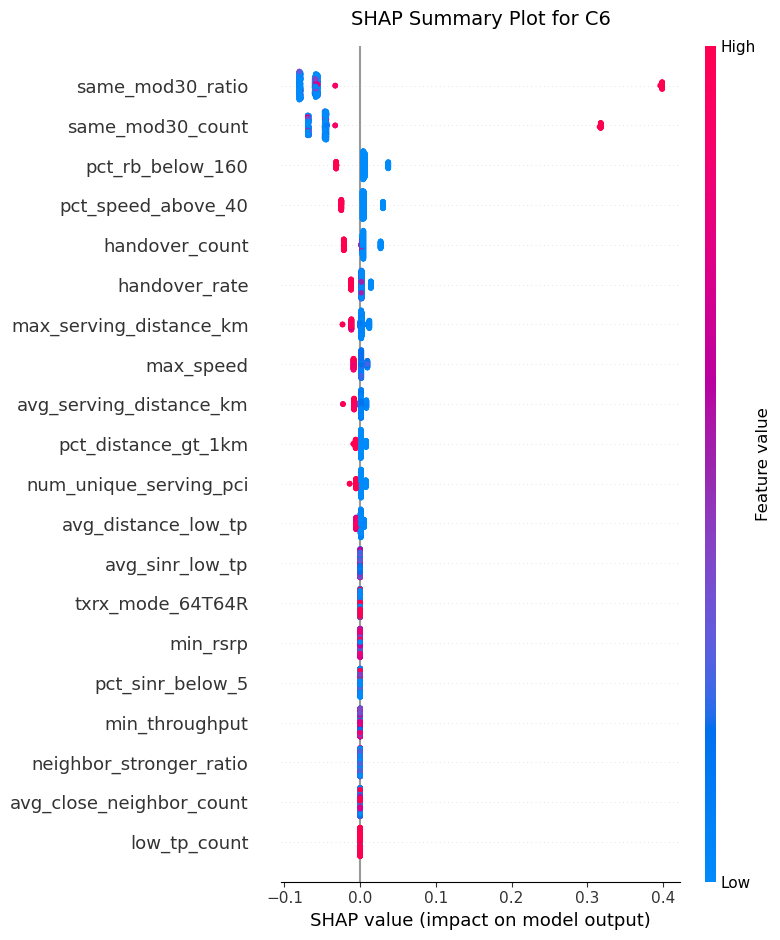

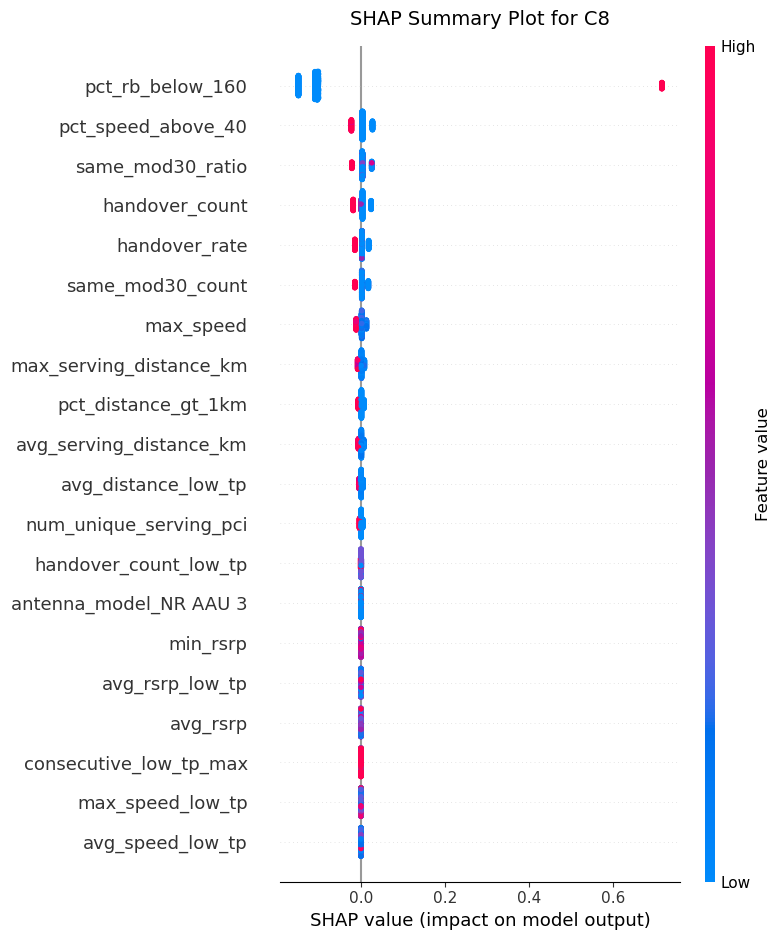

In [78]:
import matplotlib.pyplot as plt

for class_name in ["C2", "C6", "C8"]:
    
    class_idx = list(best_rf.classes_).index(class_name)

    if isinstance(shap_values, list):
        shap_class = shap_values[class_idx]
    else:
        shap_class = shap_values[:, :, class_idx]

    plt.figure(figsize=(8,6))

    shap.summary_plot(
        shap_class,
        X_test,
        feature_names=X_test.columns,
        show=False
    )

    plt.title(
        f"SHAP Summary Plot for {class_name}",
        fontsize=14,
        pad=15
    )

    plt.tight_layout()
    plt.show()

##### SHAP intepretation for C2
Class-specific SHAP analysis for **C2 (Coverage Overshooting)** revealed that distance-related KPIs were the strongest drivers of model prediction. Features such as `max_serving_distance_km`, `avg_serving_distance_km`, `pct_distance_gt_1km`, and `avg_distance_low_tp` exhibited the highest SHAP impact, with larger values substantially increasing the likelihood of C2 classification. This finding strongly aligns with telecom expectations, as overshooting scenarios occur when users are served by distant cells beyond optimal coverage range. Interestingly, RB scarcity (`pct_rb_below_160`) contributed negatively, suggesting that C2 is primarily a coverage issue rather than a resource limitation problem.

##### SHAP intepretation for C6 - PCI mod 30 conflicts causing interference
Class-specific SHAP analysis for C6 (PCI Conflict) revealed that engineered PCI conflict indicators (same_mod30_ratio and same_mod30_count) were the strongest drivers of model prediction. Higher values of these features substantially increased the likelihood of C6 classification, confirming that modulo-30 PCI overlap is a defining signal of interference-related degradation. In contrast, distance-related features contributed negatively, suggesting that C6 is operationally distinct from overshooting scenarios (C2). These findings strongly validate the domain-informed feature engineering strategy used to capture PCI conflict behavior. Those two same_mod30_ratio and same_mod30_count strong features are features that were manually engineered which indicates huge win.

##### SHAP intepretation for C8 - PCI mod 30 conflicts causing interference
Class-specific SHAP analysis for C8 revealed that pct_rb_below_160 was by far the strongest driver of model prediction, with higher values substantially increasing the likelihood of C8 classification. This finding strongly supports the interpretation of C8 as a resource limitation or congestion-related RCA, where insufficient radio resources become the defining network characteristic. In contrast, distance-based features and PCI conflict indicators contributed minimally, suggesting that C8 is operationally distinct from overshooting (C2) and PCI conflict (C6) scenarios. Overall, the SHAP analysis validates that the model differentiates RCA classes using engineering-consistent telecom behaviors rather than arbitrary statistical patterns.

### Random Forest External Cross Validation

In [79]:
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# Refit Random Forest on FULL train.json
# -----------------------------

X_full_train = X_encoded.copy()
y_full_train = y.copy()

best_rf = RandomForestClassifier(
    n_estimators=125,
    max_depth=13,
    max_features=None,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(
    X_full_train,
    y_full_train
)

print("Final Random Forest model refit on 100% of train.json")
print("Training shape:", X_full_train.shape)

Final Random Forest model refit on 100% of train.json
Training shape: (2400, 48)


In [80]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# If X_test_external is already prepared from Logistic Regression BEFORE scaling,
# use that version directly.

# Predict on external test set
rf_external_preds = best_rf.predict(X_test_external)
rf_external_probs = best_rf.predict_proba(X_test_external)

# Accuracy
print("Random Forest External Test Accuracy:")
print(accuracy_score(y_test_external, rf_external_preds))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_external, rf_external_preds))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_external, rf_external_preds))

# Metrics table
rf_report = classification_report(
    y_test_external,
    rf_external_preds,
    output_dict=True
)

rf_metrics_df = pd.DataFrame(rf_report).transpose().round(3)
rf_metrics_df

Random Forest External Test Accuracy:
0.9305555555555556

Confusion Matrix:
[[ 83   0  16   9   0   0   0   0]
 [  0 108   0   0   0   0   0   0]
 [  1   0 100   7   0   0   0   0]
 [  1   0  26  81   0   0   0   0]
 [  0   0   0   0 108   0   0   0]
 [  0   0   0   0   0 108   0   0]
 [  0   0   0   0   0   0 108   0]
 [  0   0   0   0   0   0   0 108]]

Classification Report:
              precision    recall  f1-score   support

          C1       0.98      0.77      0.86       108
          C2       1.00      1.00      1.00       108
          C3       0.70      0.93      0.80       108
          C4       0.84      0.75      0.79       108
          C5       1.00      1.00      1.00       108
          C6       1.00      1.00      1.00       108
          C7       1.00      1.00      1.00       108
          C8       1.00      1.00      1.00       108

    accuracy                           0.93       864
   macro avg       0.94      0.93      0.93       864
weighted avg       0.94

,precision,recall,f1-score,support
C1,0.976,0.769,0.860,108.000
C2,1.000,1.000,1.000,108.000
C3,0.704,0.926,0.800,108.000
C4,0.835,0.750,0.790,108.000
C5,1.000,1.000,1.000,108.000
C6,1.000,1.000,1.000,108.000
C7,1.000,1.000,1.000,108.000
C8,1.000,1.000,1.000,108.000
accuracy,0.931,0.931,0.931,0.931
macro avg,0.939,0.931,0.931,864.000


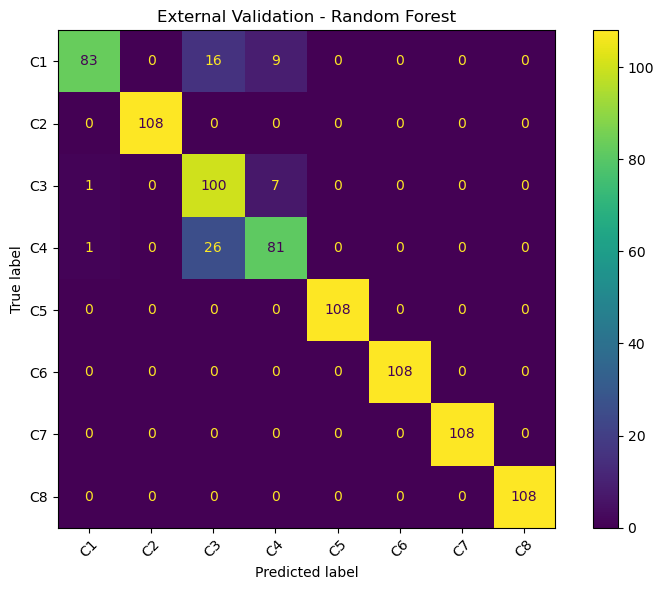

In [81]:
cm = confusion_matrix(y_test_external, rf_external_preds)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_rf.classes_
)

disp.plot(ax=ax)

plt.title("External Validation - Random Forest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. XGBoost
### XGBoost - Grid Search

In [82]:
import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer, f1_score

# -----------------------------
# X and y
# -----------------------------

X = X_encoded.copy()
y = ml_df["answer"]

# -----------------------------
# Encode target labels
# C1, C2, ... -> 0, 1, ...
# -----------------------------

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Class mapping:")
for original, encoded in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(original, "->", encoded)

# -----------------------------
# Train/Test split
# -----------------------------
# If you already have X_train, X_test, y_train, y_test from before,
# you can skip this and just encode y_train/y_test.
# But this keeps it clean.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# -----------------------------
# XGBoost model
# -----------------------------

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=1
)


# -----------------------------
# CV setup
# -----------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

# Macro F1 scorer
f1_macro_scorer = make_scorer(
    f1_score,
    average="macro"
)

# -----------------------------
# GridSearchCV
# -----------------------------

param_grid = {
    "n_estimators": [125, 150, 175, 200],
    "max_depth": [5, 6, 7],
    "learning_rate": [0.07, 0.1, 0.12, 0.15],
    "subsample": [0.9, 1.0],
    "colsample_bytree": [0.9, 1.0]
}



xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=1,
    verbose=2
)

xgb_grid.fit(X_train, y_train)

print("Best Parameters:")
print(xgb_grid.best_params_)

print("\nBest CV Macro F1:")
print(xgb_grid.best_score_)

Class mapping:
C1 -> 0
C2 -> 1
C3 -> 2
C4 -> 3
C5 -> 4
C6 -> 5
C7 -> 6
C8 -> 7
Fitting 5 folds for each of 192 candidates, totalling 960 fits
[CV] END colsample_bytree=0.9, learning_rate=0.07, max_depth=5, n_estimators=125, subsample=0.9; total time=   0.3s
[CV] END colsample_bytree=0.9, learning_rate=0.07, max_depth=5, n_estimators=125, subsample=0.9; total time=   0.3s
[CV] END colsample_bytree=0.9, learning_rate=0.07, max_depth=5, n_estimators=125, subsample=0.9; total time=   0.3s
[CV] END colsample_bytree=0.9, learning_rate=0.07, max_depth=5, n_estimators=125, subsample=0.9; total time=   0.3s
[CV] END colsample_bytree=0.9, learning_rate=0.07, max_depth=5, n_estimators=125, subsample=0.9; total time=   0.3s
[CV] END colsample_bytree=0.9, learning_rate=0.07, max_depth=5, n_estimators=125, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.9, learning_rate=0.07, max_depth=5, n_estimators=125, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.9, learning_rate=0

Best Parameters:
{'colsample_bytree': 0.9, 'learning_rate': 0.15, 'max_depth': 6, 'n_estimators': 175, 'subsample': 0.9}

Best CV Macro F1:
0.9577295031895614

### Fit XGBoost Model with best Parameters

In [83]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

best_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    colsample_bytree=0.9,
    learning_rate=0.15,
    max_depth=6,
    n_estimators=175,
    subsample=0.9,
    random_state=42,
    n_jobs=1
)

best_xgb.fit(X_train, y_train)

xgb_preds = best_xgb.predict(X_test)
xgb_probs = best_xgb.predict_proba(X_test)

In [84]:
y_test_labels = label_encoder.inverse_transform(y_test)
xgb_pred_labels = label_encoder.inverse_transform(xgb_preds)

### XGBoost Evaluation Metrics

In [85]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

xgb_accuracy = accuracy_score(y_test, xgb_preds)

xgb_precision = precision_score(
    y_test,
    xgb_preds,
    average="macro"
)

xgb_recall = recall_score(
    y_test,
    xgb_preds,
    average="macro"
)

xgb_f1 = f1_score(
    y_test,
    xgb_preds,
    average="macro"
)

xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_probs,
    multi_class="ovr",
    average="macro"
)

print("XGBoost Results")
print("Accuracy:", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall:", xgb_recall)
print("F1:", xgb_f1)
print("ROC-AUC:", xgb_roc_auc)

print("\nClassification Report:")
print(
    classification_report(
        y_test_labels,
        xgb_pred_labels
    )
)

XGBoost Results
Accuracy: 0.9541666666666667
Precision: 0.9566977169655742
Recall: 0.953020146850832
F1: 0.9544418310802582
ROC-AUC: 0.997684611431555

Classification Report:
              precision    recall  f1-score   support

          C1       0.98      0.91      0.94        53
          C2       1.00      1.00      1.00        64
          C3       0.82      0.89      0.86        66
          C4       0.85      0.82      0.84        57
          C5       1.00      1.00      1.00        70
          C6       1.00      1.00      1.00        45
          C7       1.00      1.00      1.00        70
          C8       1.00      1.00      1.00        55

    accuracy                           0.95       480
   macro avg       0.96      0.95      0.95       480
weighted avg       0.96      0.95      0.95       480



### XGBoost - Confusion Metrics

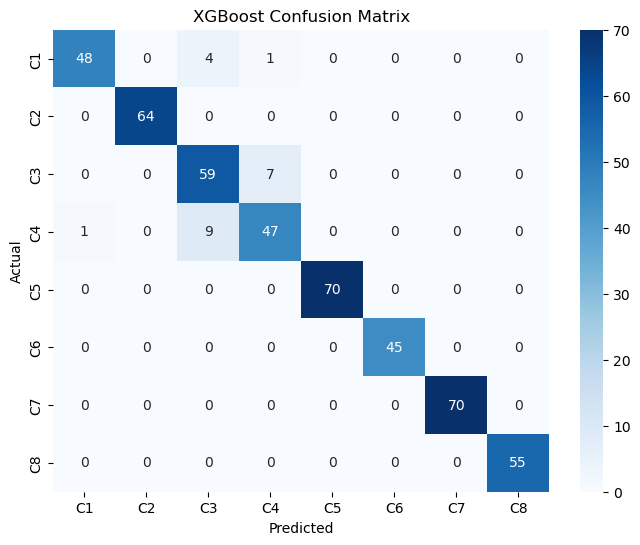

In [86]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

xgb_cm = confusion_matrix(
    y_test_labels,
    xgb_pred_labels,
    labels=label_encoder.classes_
)

plt.figure(figsize=(8,6))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [87]:
import pandas as pd
from sklearn.metrics import confusion_matrix

xgb_youden_results = []

for cls in label_encoder.classes_:
    y_true_binary = (y_test_labels == cls).astype(int)
    y_pred_binary = (xgb_pred_labels == cls).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true_binary,
        y_pred_binary
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youden_j = sensitivity + specificity - 1

    xgb_youden_results.append({
        "RCA": cls,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Youden_J": youden_j
    })

xgb_youden_df = pd.DataFrame(xgb_youden_results)

display(
    xgb_youden_df.sort_values(
        "Youden_J",
        ascending=False
    ).round(3)
)

,RCA,Sensitivity,Specificity,Youden_J
1,C2,1.000,1.000,1.000
4,C5,1.000,1.000,1.000
5,C6,1.000,1.000,1.000
6,C7,1.000,1.000,1.000
7,C8,1.000,1.000,1.000
0,C1,0.906,0.998,0.903
2,C3,0.894,0.969,0.863
3,C4,0.825,0.981,0.806


### XGBoost - Feature Importance

In [88]:
xgb_feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_xgb.feature_importances_
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    "importance",
    ascending=False
)

display(xgb_feature_importance.head(20))

,feature,importance
11,num_unique_serving_pci,0.232561
12,handover_count,0.130236
35,same_mod30_count,0.108308
7,max_speed,0.104482
13,handover_rate,0.071217
24,avg_rb,0.053479
8,pct_speed_above_40,0.044707
16,min_rsrp,0.032737
3,low_tp_count,0.028072
33,overlap_ratio,0.023820


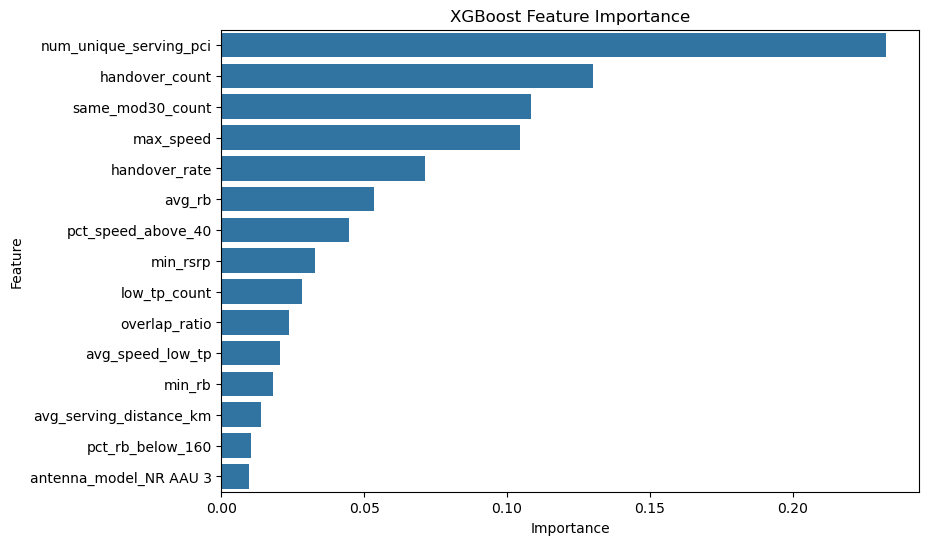

In [89]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=xgb_feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### XGBoost - ROC Curve — Multiclass One-vs-Rest

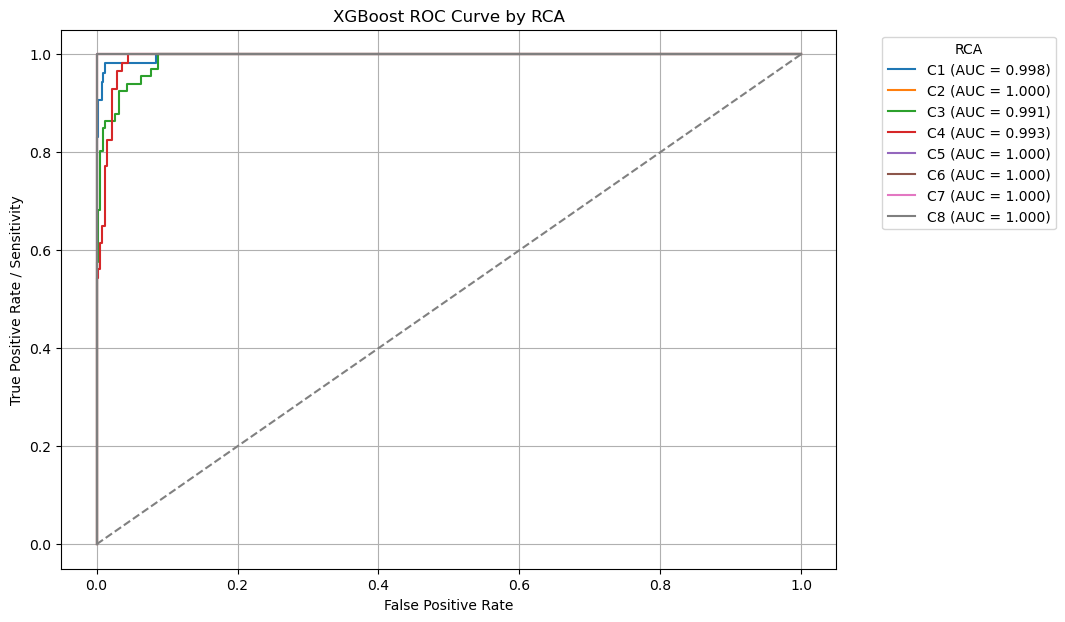

In [90]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

classes = label_encoder.classes_

y_test_bin = label_binarize(
    y_test_labels,
    classes=classes
)

plt.figure(figsize=(10,7))

xgb_roc_auc_dict = {}

for i, cls in enumerate(classes):
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        xgb_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)
    xgb_roc_auc_dict[cls] = roc_auc

    plt.plot(
        fpr,
        tpr,
        label=f"{cls} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

plt.title("XGBoost ROC Curve by RCA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

plt.show()

### XGBoost Precision-Recall Curve — Multiclass One-vs-Rest

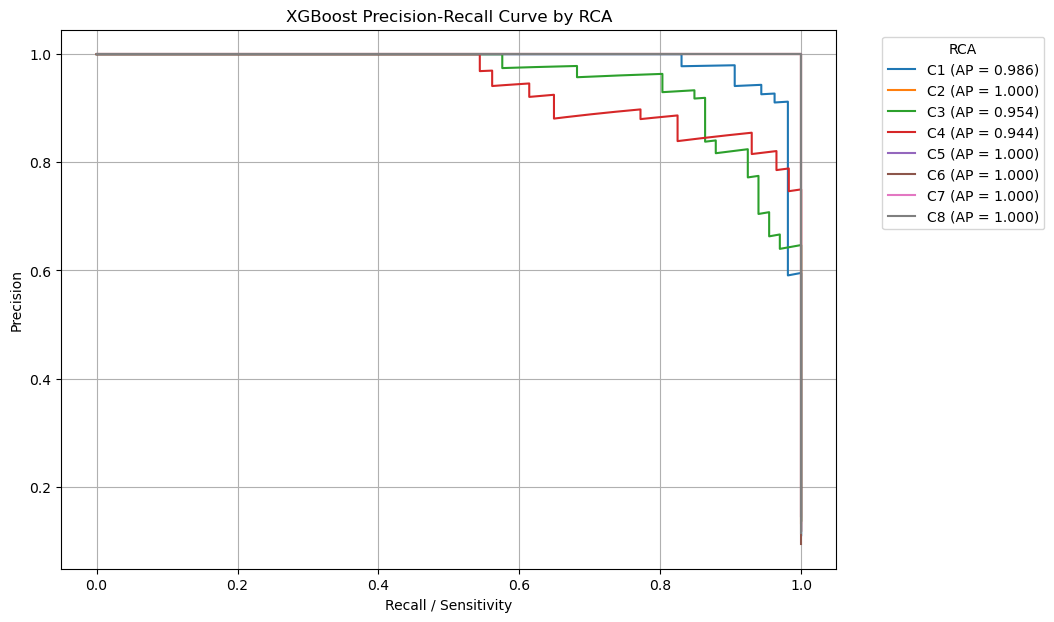

In [91]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10,7))

xgb_pr_auc_dict = {}

for i, cls in enumerate(classes):
    precision, recall, thresholds = precision_recall_curve(
        y_test_bin[:, i],
        xgb_probs[:, i]
    )

    avg_precision = average_precision_score(
        y_test_bin[:, i],
        xgb_probs[:, i]
    )

    xgb_pr_auc_dict[cls] = avg_precision

    plt.plot(
        recall,
        precision,
        label=f"{cls} (AP = {avg_precision:.3f})"
    )

plt.title("XGBoost Precision-Recall Curve by RCA")
plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

plt.show()

### Internal 5-fold Cross Validaton

In [92]:
from sklearn.model_selection import StratifiedKFold, cross_validate

xgb_cv_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    colsample_bytree=0.9,
    learning_rate=0.15,
    max_depth=6,
    n_estimators=175,
    subsample=0.9,
    random_state=42,
    n_jobs=1
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc_ovr": "roc_auc_ovr"
}

xgb_cv_results = cross_validate(
    xgb_cv_model,
    X_encoded,
    y_encoded,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=True
)

for metric in scoring.keys():
    train_scores = xgb_cv_results[f"train_{metric}"]
    test_scores = xgb_cv_results[f"test_{metric}"]

    print(metric)
    print(f"  Train: {train_scores.mean():.3f} ({train_scores.std():.3f})")
    print(f"  Test : {test_scores.mean():.3f} ({test_scores.std():.3f})")
    print("-" * 40)

accuracy
  Train: 1.000 (0.000)
  Test : 0.955 (0.005)
----------------------------------------
precision_macro
  Train: 1.000 (0.000)
  Test : 0.957 (0.005)
----------------------------------------
recall_macro
  Train: 1.000 (0.000)
  Test : 0.954 (0.005)
----------------------------------------
f1_macro
  Train: 1.000 (0.000)
  Test : 0.955 (0.005)
----------------------------------------
roc_auc_ovr
  Train: 1.000 (0.000)
  Test : 0.998 (0.000)
----------------------------------------


| Model               |  Accuracy | Precision Macro | Recall Macro |  F1 Macro |   ROC-AUC |
| ------------------- | --------: | --------------: | -----------: | --------: | --------: |
| Logistic Regression |     0.946 |           0.946 |        0.945 |     0.945 |     0.996 |
| Random Forest       |     0.944 |           0.946 |        0.943 |     0.944 |     0.996 |
| **XGBoost**         | **0.954** |       **0.957** |    **0.953** | **0.954** | **0.998** |


**Key observations:**

XGBoost improved overall performance, especially Macro F1: 0.954 vs. 0.945 for Logistic Regression.
C2, C5, C6, C7, and C8 were perfectly classified, which matches your EDA and SHAP findings.
C3 and C4 are still the hardest classes, but XGBoost improved C3 recall to 0.894 and C3 F1 to 0.86.
The confusion is still mainly C3 ↔ C4, suggesting these two RCA types have genuinely overlapping KPI signatures.
CV test Macro F1 = 0.955, which matches the holdout result very well.
Train CV = 1.000, so XGBoost is fitting training data perfectly, but the stable test CV suggests performance is still strong. I would describe this as high model capacity with good validation performance, not a failure.

XGBoost achieved the strongest overall performance, suggesting that nonlinear boosted trees can capture additional RCA structure beyond Logistic Regression and Random Forest, especially for more ambiguous classes such as C3 and C4. However, the remaining C3/C4 confusion indicates that these RCA mechanisms may share similar telecom KPI patterns.

### XGBoost - External Cross Valdation

In [93]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode RCA labels using FULL train.json
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Class mapping:")
for original, encoded in zip(
    label_encoder.classes_,
    range(len(label_encoder.classes_))
):
    print(original, "->", encoded)

# -----------------------------
# Refit XGBoost on FULL train.json
# -----------------------------

X_full_train = X_encoded.copy()
y_full_train = y_encoded.copy()

best_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    colsample_bytree=0.9,
    learning_rate=0.15,
    max_depth=6,
    n_estimators=175,
    subsample=0.9,
    random_state=42,
    n_jobs=1
)

best_xgb.fit(
    X_full_train,
    y_full_train
)

print("Final XGBoost model refit on 100% of train.json")
print("Training shape:", X_full_train.shape)

Class mapping:
C1 -> 0
C2 -> 1
C3 -> 2
C4 -> 3
C5 -> 4
C6 -> 5
C7 -> 6
C8 -> 7
Final XGBoost model refit on 100% of train.json
Training shape: (2400, 48)


In [94]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# External X data should already be prepared:
# - one-hot encoded
# - reindexed to X_train.columns
# - median imputed
# - NOT scaled

X_test_external_xgb = X_test_external.copy()

# Encode external y labels using the SAME label encoder
y_test_external_encoded = label_encoder.transform(y_test_external)

# Predict
xgb_external_preds_encoded = best_xgb.predict(X_test_external_xgb)
xgb_external_probs = best_xgb.predict_proba(X_test_external_xgb)

# Convert predictions back to original labels
xgb_external_preds = label_encoder.inverse_transform(
    xgb_external_preds_encoded.astype(int)
)

# Evaluation
print("XGBoost External Test Accuracy:")
print(accuracy_score(y_test_external, xgb_external_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_external, xgb_external_preds))

print("\nClassification Report:")
print(classification_report(y_test_external, xgb_external_preds))

XGBoost External Test Accuracy:
0.9131944444444444

Confusion Matrix:
[[ 85   0   9   3   0   0   0  11]
 [  0 108   0   0   0   0   0   0]
 [  0   0  91   3   0   0   0  14]
 [  3   0  15  73   0   0   0  17]
 [  0   0   0   0 108   0   0   0]
 [  0   0   0   0   0 108   0   0]
 [  0   0   0   0   0   0 108   0]
 [  0   0   0   0   0   0   0 108]]

Classification Report:
              precision    recall  f1-score   support

          C1       0.97      0.79      0.87       108
          C2       1.00      1.00      1.00       108
          C3       0.79      0.84      0.82       108
          C4       0.92      0.68      0.78       108
          C5       1.00      1.00      1.00       108
          C6       1.00      1.00      1.00       108
          C7       1.00      1.00      1.00       108
          C8       0.72      1.00      0.84       108

    accuracy                           0.91       864
   macro avg       0.93      0.91      0.91       864
weighted avg       0.93      

In [95]:
xgb_report = classification_report(
    y_test_external,
    xgb_external_preds,
    output_dict=True
)

xgb_metrics_df = pd.DataFrame(xgb_report).transpose().round(3)
xgb_metrics_df

,precision,recall,f1-score,support
C1,0.966,0.787,0.867,108.000
C2,1.000,1.000,1.000,108.000
C3,0.791,0.843,0.816,108.000
C4,0.924,0.676,0.781,108.000
C5,1.000,1.000,1.000,108.000
C6,1.000,1.000,1.000,108.000
C7,1.000,1.000,1.000,108.000
C8,0.720,1.000,0.837,108.000
accuracy,0.913,0.913,0.913,0.913
macro avg,0.925,0.913,0.913,864.000


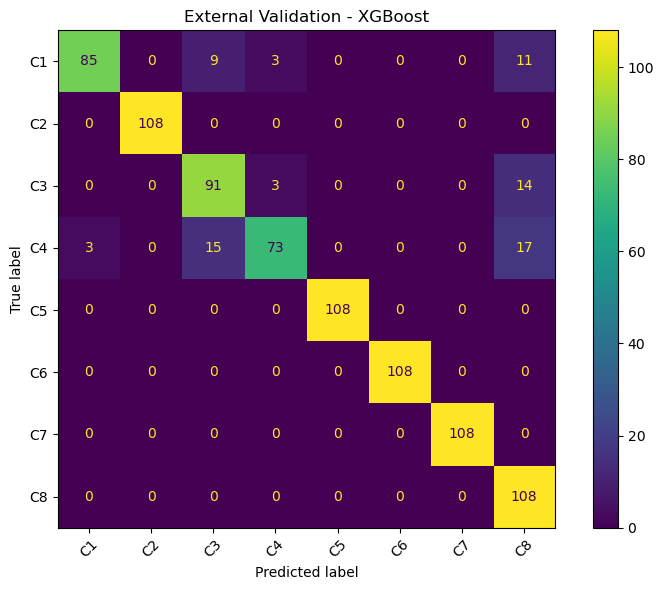

In [96]:
cm = confusion_matrix(y_test_external, xgb_external_preds)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(ax=ax)

plt.title("External Validation - XGBoost")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Light GBM

### Light GBM - Grid Search

In [97]:
#!pip install lightgbm

In [98]:
{'colsample_bytree': 0.7, 'learning_rate': 0.15, 'max_depth': 7, 'n_estimators': 250, 'num_leaves': 63, 'subsample': 0.7}

{'colsample_bytree': 0.7,
 'learning_rate': 0.15,
 'max_depth': 7,
 'n_estimators': 250,
 'num_leaves': 63,
 'subsample': 0.7}

In [99]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

lgbm_model = LGBMClassifier(
    objective="multiclass",
    num_class=len(label_encoder.classes_),
    random_state=42,
    n_jobs=1,
    verbose=-1
)

param_grid_lgbm = {
    "n_estimators": [240,250, 260],
    "max_depth": [6,7],
    "learning_rate": [0.1, 0.15, 0.17],
    "num_leaves": [61,63,65],
    "subsample": [0.6, 0.7, 0.8],
    "colsample_bytree": [0.6,0.7, 0.8]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

lgbm_grid = GridSearchCV(
    estimator=lgbm_model,
    param_grid=param_grid_lgbm,
    scoring="f1_macro",
    cv=cv,
    n_jobs=1,
    verbose=2
)

lgbm_grid.fit(X_train, y_train)

print("Best Parameters:")
print(lgbm_grid.best_params_)

print("\nBest CV Macro F1:")
print(lgbm_grid.best_score_)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=6, n_estimators=240, num_leaves=61, subsample=0.6; total time=   0.5s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=6, n_estimators=240, num_leaves=61, subsample=0.6; total time=   0.5s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=6, n_estimators=240, num_leaves=61, subsample=0.6; total time=   0.5s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=6, n_estimators=240, num_leaves=61, subsample=0.6; total time=   0.5s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=6, n_estimators=240, num_leaves=61, subsample=0.6; total time=   0.5s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=6, n_estimators=240, num_leaves=61, subsample=0.7; total time=   0.5s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=6, n_estimators=240, num_leaves=61, subsample=0.7; total time=   0.5s
[CV] END colsample_bytree=

Best Parameters:
{'colsample_bytree': 0.7, 'learning_rate': 0.15, 'max_depth': 7, 'n_estimators': 250, 'num_leaves': 63, 'subsample': 0.7}

Best CV Macro F1:
0.9581297910488621

Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.17, 'max_depth': 7, 'n_estimators': 260, 'num_leaves': 61, 'subsample': 0.6}

Best CV Macro F1:
0.9590999360155044

In [100]:
best_lgbm = lgbm_grid.best_estimator_

best_lgbm.fit(X_train, y_train)

lgbm_preds = best_lgbm.predict(X_test)
lgbm_probs = best_lgbm.predict_proba(X_test)

# Convert labels back to C1–C8
y_test_labels = label_encoder.inverse_transform(y_test)
lgbm_pred_labels = label_encoder.inverse_transform(lgbm_preds)

### Light GBM - Metrics

In [101]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

lgbm_accuracy = accuracy_score(y_test, lgbm_preds)
lgbm_precision = precision_score(y_test, lgbm_preds, average="macro")
lgbm_recall = recall_score(y_test, lgbm_preds, average="macro")
lgbm_f1 = f1_score(y_test, lgbm_preds, average="macro")
lgbm_roc_auc = roc_auc_score(
    y_test,
    lgbm_probs,
    multi_class="ovr",
    average="macro"
)

print("LightGBM Results")
print("Accuracy:", lgbm_accuracy)
print("Precision:", lgbm_precision)
print("Recall:", lgbm_recall)
print("F1:", lgbm_f1)
print("ROC-AUC:", lgbm_roc_auc)

print("\nClassification Report:")
print(classification_report(y_test_labels, lgbm_pred_labels))

LightGBM Results
Accuracy: 0.95
Precision: 0.9521870808182428
Recall: 0.9487677168908549
F1: 0.9500322244805901
ROC-AUC: 0.9975332479923293

Classification Report:
              precision    recall  f1-score   support

          C1       0.98      0.89      0.93        53
          C2       1.00      1.00      1.00        64
          C3       0.82      0.88      0.85        66
          C4       0.84      0.82      0.83        57
          C5       1.00      1.00      1.00        70
          C6       1.00      1.00      1.00        45
          C7       1.00      1.00      1.00        70
          C8       0.98      1.00      0.99        55

    accuracy                           0.95       480
   macro avg       0.95      0.95      0.95       480
weighted avg       0.95      0.95      0.95       480



### Light GBM - Confusion Matrix

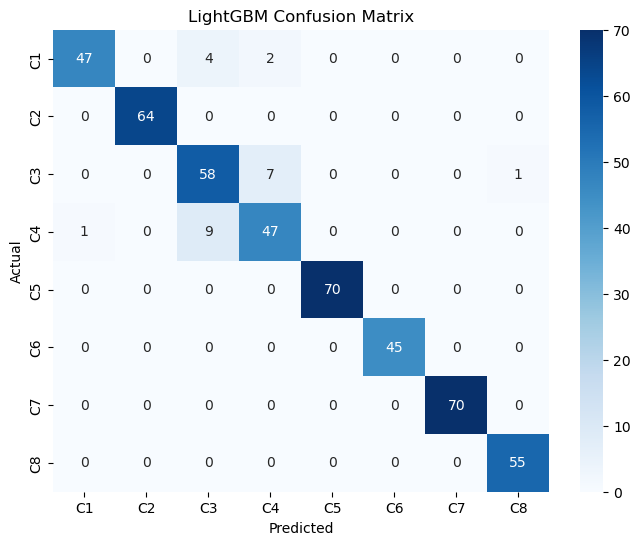

In [102]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

lgbm_cm = confusion_matrix(
    y_test_labels,
    lgbm_pred_labels,
    labels=label_encoder.classes_
)

plt.figure(figsize=(8,6))

sns.heatmap(
    lgbm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Light GBM -  Sensitivity, specificity, Youden’s J

In [103]:
lgbm_youden_results = []

for cls in label_encoder.classes_:
    y_true_binary = (y_test_labels == cls).astype(int)
    y_pred_binary = (lgbm_pred_labels == cls).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true_binary,
        y_pred_binary
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youden_j = sensitivity + specificity - 1

    lgbm_youden_results.append({
        "RCA": cls,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Youden_J": youden_j
    })

lgbm_youden_df = pd.DataFrame(lgbm_youden_results)

display(
    lgbm_youden_df.sort_values(
        "Youden_J",
        ascending=False
    ).round(3)
)

,RCA,Sensitivity,Specificity,Youden_J
1,C2,1.000,1.000,1.000
4,C5,1.000,1.000,1.000
5,C6,1.000,1.000,1.000
6,C7,1.000,1.000,1.000
7,C8,1.000,0.998,0.998
0,C1,0.887,0.998,0.884
2,C3,0.879,0.969,0.847
3,C4,0.825,0.979,0.803


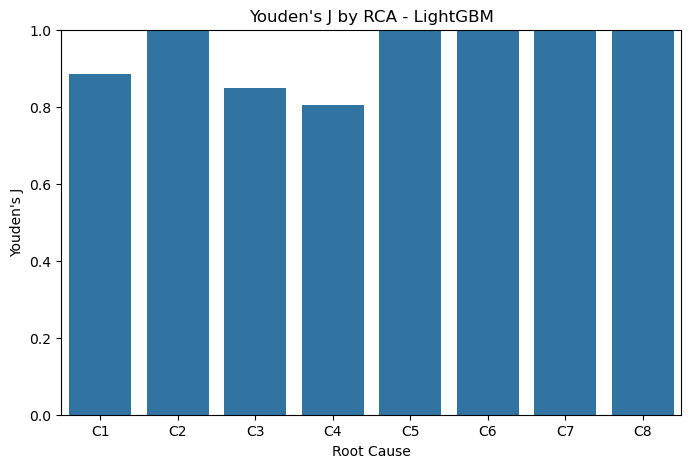

In [104]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=lgbm_youden_df,
    x="RCA",
    y="Youden_J",
    order=label_encoder.classes_
)

plt.title("Youden's J by RCA - LightGBM")
plt.xlabel("Root Cause")
plt.ylabel("Youden's J")
plt.ylim(0, 1)
plt.show()

### Light GBM - Feature importance

In [105]:
lgbm_feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_lgbm.feature_importances_
})

lgbm_feature_importance = lgbm_feature_importance.sort_values(
    "importance",
    ascending=False
)

display(lgbm_feature_importance.head(20))

,feature,importance
30,max_neighbor_advantage,1283
5,avg_throughput_low_tp,1072
29,avg_neighbor_advantage,968
0,avg_throughput,946
32,avg_close_neighbor_count,790
1,min_throughput,787
2,std_throughput,764
37,avg_serving_tilt,703
17,avg_rsrp_low_tp,696
16,min_rsrp,676


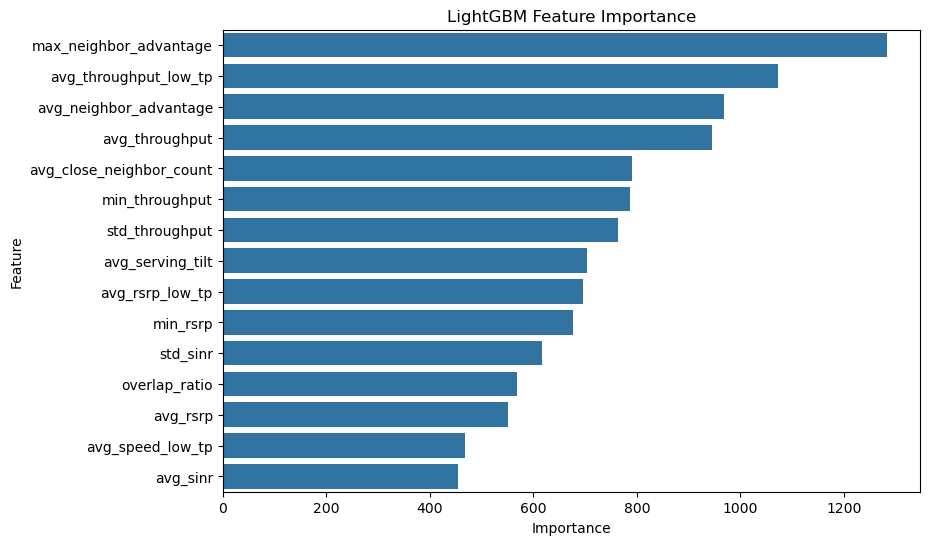

In [106]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=lgbm_feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Light GBM - ROC curve

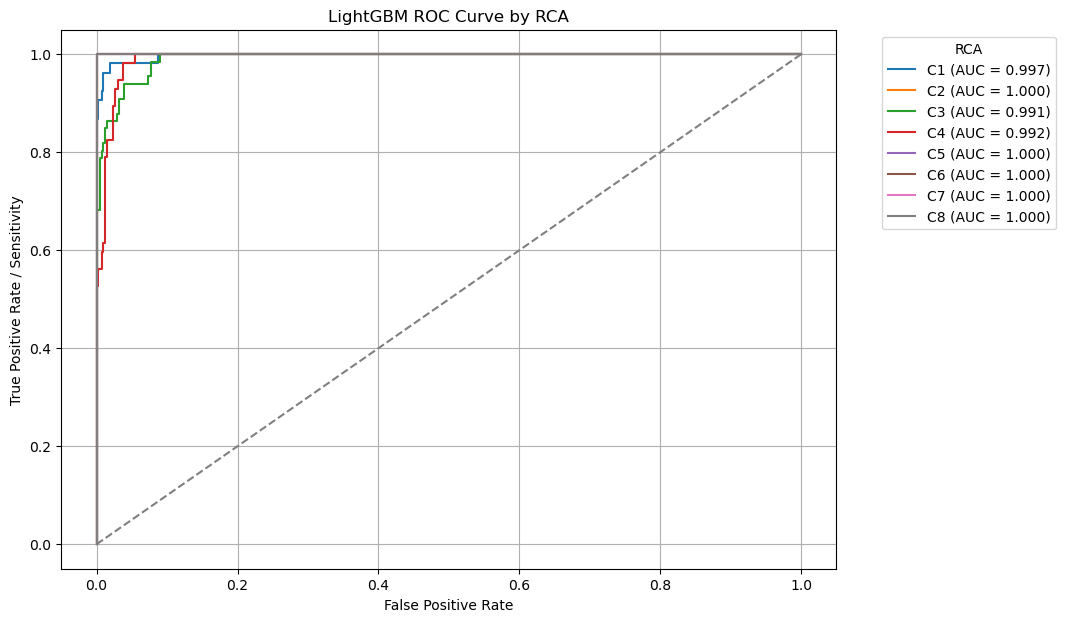

In [107]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = label_encoder.classes_

y_test_bin = label_binarize(
    y_test_labels,
    classes=classes
)

plt.figure(figsize=(10,7))

lgbm_roc_auc_dict = {}

for i, cls in enumerate(classes):
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        lgbm_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)
    lgbm_roc_auc_dict[cls] = roc_auc

    plt.plot(
        fpr,
        tpr,
        label=f"{cls} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.title("LightGBM ROC Curve by RCA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

### Light GBM - Precision-Recall Curve

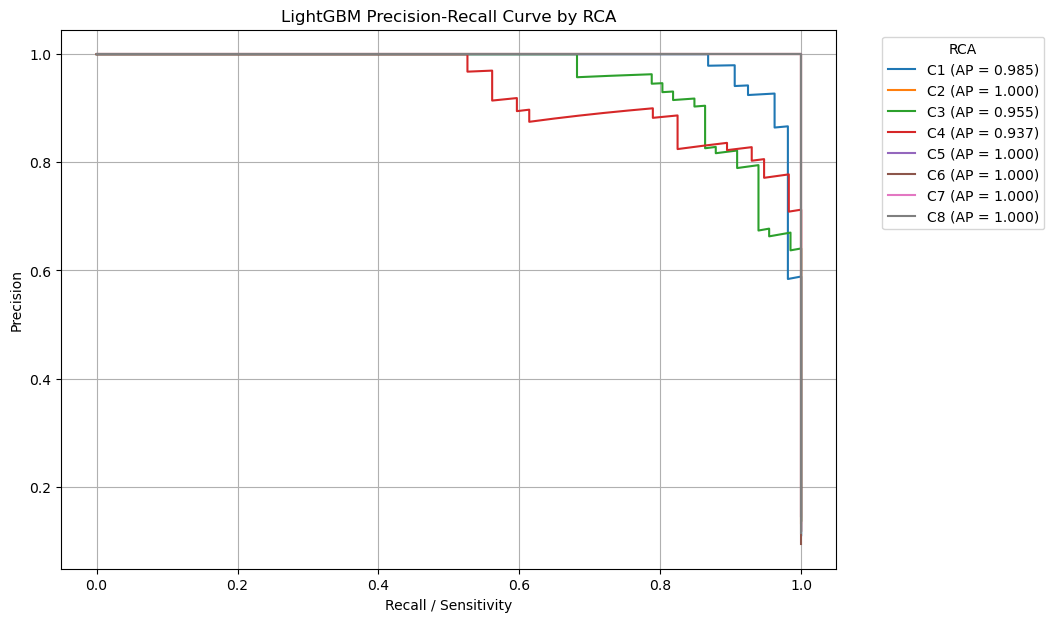

In [108]:
### Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10,7))

lgbm_pr_auc_dict = {}

for i, cls in enumerate(classes):
    precision, recall, thresholds = precision_recall_curve(
        y_test_bin[:, i],
        lgbm_probs[:, i]
    )

    avg_precision = average_precision_score(
        y_test_bin[:, i],
        lgbm_probs[:, i]
    )

    lgbm_pr_auc_dict[cls] = avg_precision

    plt.plot(
        recall,
        precision,
        label=f"{cls} (AP = {avg_precision:.3f})"
    )

plt.title("LightGBM Precision-Recall Curve by RCA")
plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

### Light GBM - Internal CV

In [109]:
from sklearn.model_selection import cross_validate

lgbm_cv_model = LGBMClassifier(
    objective="multiclass",
    num_class=len(label_encoder.classes_),
    **lgbm_grid.best_params_,
    random_state=42,
    n_jobs=1,
    verbose=-1
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc_ovr": "roc_auc_ovr"
}

lgbm_cv_results = cross_validate(
    lgbm_cv_model,
    X_encoded,
    y_encoded,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=True
)

for metric in scoring.keys():
    train_scores = lgbm_cv_results[f"train_{metric}"]
    test_scores = lgbm_cv_results[f"test_{metric}"]

    print(metric)
    print(f"  Train: {train_scores.mean():.3f} ({train_scores.std():.3f})")
    print(f"  Test : {test_scores.mean():.3f} ({test_scores.std():.3f})")
    print("-" * 40)

accuracy
  Train: 1.000 (0.000)
  Test : 0.957 (0.006)
----------------------------------------
precision_macro
  Train: 1.000 (0.000)
  Test : 0.959 (0.006)
----------------------------------------
recall_macro
  Train: 1.000 (0.000)
  Test : 0.956 (0.006)
----------------------------------------
f1_macro
  Train: 1.000 (0.000)
  Test : 0.957 (0.006)
----------------------------------------
roc_auc_ovr
  Train: 1.000 (0.000)
  Test : 0.998 (0.001)
----------------------------------------


### Light GBM - External cross validation

In [114]:
from lightgbm import LGBMClassifier

# -----------------------------
# Refit LightGBM on FULL train.json
# -----------------------------

X_full_train = X_encoded.copy()
y_full_train = y_encoded.copy()

best_lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=len(label_encoder.classes_),
    colsample_bytree=0.8,
    learning_rate=0.17,
    max_depth=7,
    n_estimators=260,
    num_leaves=61,
    subsample=0.6,
    random_state=42,
    n_jobs=1,
    verbose=-1
)



best_lgbm.fit(
    X_full_train,
    y_full_train
)

print("Final LightGBM model refit on 100% of train.json")
print("Training shape:", X_full_train.shape)

Final LightGBM model refit on 100% of train.json
Training shape: (2400, 48)


In [115]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

# Predict numeric labels
lgbm_external_preds_encoded = best_lgbm.predict(X_test_external)
lgbm_external_probs = best_lgbm.predict_proba(X_test_external)

# Convert numeric predictions back to original RCA labels
lgbm_external_preds = label_encoder.inverse_transform(
    lgbm_external_preds_encoded.astype(int)
)

# Evaluation
print("LightGBM External Test Accuracy:")
print(accuracy_score(y_test_external, lgbm_external_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_external, lgbm_external_preds))

print("\nClassification Report:")
print(classification_report(y_test_external, lgbm_external_preds))

LightGBM External Test Accuracy:
0.9432870370370371

Confusion Matrix:
[[ 93   0  12   3   0   0   0   0]
 [  0 108   0   0   0   0   0   0]
 [  2   0 102   4   0   0   0   0]
 [  6   0  22  80   0   0   0   0]
 [  0   0   0   0 108   0   0   0]
 [  0   0   0   0   0 108   0   0]
 [  0   0   0   0   0   0 108   0]
 [  0   0   0   0   0   0   0 108]]

Classification Report:
              precision    recall  f1-score   support

          C1       0.92      0.86      0.89       108
          C2       1.00      1.00      1.00       108
          C3       0.75      0.94      0.84       108
          C4       0.92      0.74      0.82       108
          C5       1.00      1.00      1.00       108
          C6       1.00      1.00      1.00       108
          C7       1.00      1.00      1.00       108
          C8       1.00      1.00      1.00       108

    accuracy                           0.94       864
   macro avg       0.95      0.94      0.94       864
weighted avg       0.95     

In [116]:
# Metrics table for external cross validation
lgbm_report = classification_report(
    y_test_external,
    lgbm_external_preds,
    output_dict=True
)

lgbm_metrics_df = pd.DataFrame(lgbm_report).transpose().round(3)
lgbm_metrics_df

,precision,recall,f1-score,support
C1,0.921,0.861,0.890,108.000
C2,1.000,1.000,1.000,108.000
C3,0.750,0.944,0.836,108.000
C4,0.920,0.741,0.821,108.000
C5,1.000,1.000,1.000,108.000
C6,1.000,1.000,1.000,108.000
C7,1.000,1.000,1.000,108.000
C8,1.000,1.000,1.000,108.000
accuracy,0.943,0.943,0.943,0.943
macro avg,0.949,0.943,0.943,864.000


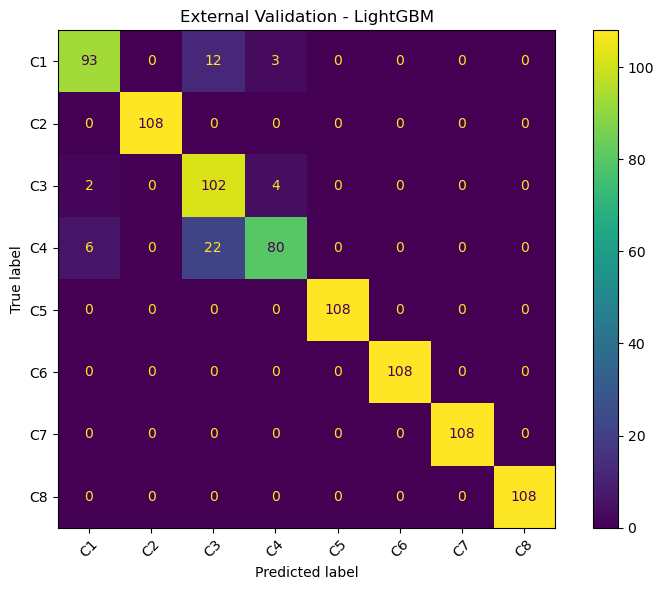

In [117]:
# Consuion Metrics
cm = confusion_matrix(y_test_external, lgbm_external_preds)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(ax=ax)

plt.title("External Validation - LightGBM")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Overall all models are struggling to classify c1, c3, c4 

| RCA | Main mechanism        |
| --- | --------------------- |
| C1  | weak coverage         |
| C3  | neighboring dominance |
| C4  | overlap/interference  |


# Business Loss function

Assumptions
FP (wrong investigation)

Cost:1


FN (missed true RCA)

Multiplier:3

| RCA | Severity |
| --- | -------: |
| C1  |        3 |
| C2  |        3 |
| C3  |        2 |
| C4  |        4 |
| C5  |        3 |
| C6  |        3 |
| C7  |        1 |
| C8  |        4 |


Then:

$$Cost=(FN multiplier×Actual RCA severity)+(FP cost)$$

So per-mistake costs become:

| Actual RCA | Cost per mistake |
| ---------- | ---------------: |
| C1         |               10 |
| C2         |               10 |
| C3         |                7 |
| C4         |               13 |
| C5         |               10 |
| C6         |               10 |
| C7         |                4 |
| C8         |               13 |


## Preliminary Business Cost Ranking

| Model               | Business Loss |
| ------------------- | ------------: |
| Logistic Regression |       **610** |
| Random Forest       |       **657** |
| XGBoost             |       **804** |


“The model with the highest predictive performance may not necessarily minimize operational RCA cost.”